# Исследовательский анализ и проверка гипотез сервиса Яндекс Афиша

- Автор: Сухостовская Светлана 
- Дата: 29.03.2026

Продуктовый отдел сервиса Яндекс Афиша заметил общее изменение в пользовательском спросе и хочет изучить возможные причины изменения. Необходимо провести исследовательский анализ данных, для анализа предоставлены 3 датасета.

* **``final_tickets_orders_df.csv``** — информация обо всех заказах билетов:
    
* **``final_tickets_events_df.csv``**— информация о событиях

* **``final_tickets_tenge_df.csv``** —  информациея о курсе тенге к российскому рублю за 2024 год:

##  Цели и задачи проекта

### Цели
1. Провести исследовательский анализ данных в Python, выявить изменения в **пользовательском поведении, структуре спроса и популярности категорий мероприятий** в осенний период 2024 года.

2. Проверить гипотезы о **разнице в поведении пользователей** с мобильными и стационарными устройствами:
    1. **Среднее количество заказов** на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
    2. **Среднее время между заказами** пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

### Задачи
#### Загрузка данных и изучение общей информации о содержимом поле, оценка объема данных
1. Импорт библиотек и загрузка данных
2. Изучение общей информации о содержимом полей, типы данных

#### Предобработка данных
1. Преобразование типов данных
2. Объединение таблиц
3. Проверка на пропуски, замена/удаление пропусков
4. Оценка значений в столбцах: 
    * **категориальные данные** проверить на неявные дубликаты
    * **количественные значения** оценить наличие выбросов в ключевых полях: **revenue, tickets_count**. Выбросы в поле **revenue** ограничить 99-м процентилем. Оценка в разрезе валют rub и kzt.

5. Проверка на дубликаты, замена/удаление дубликатов
6. Добавление новых полей: 
    * ``revenue_rub`` - привести выручку к единой валюте rub *(загрузить датасет ``final_tickets_tenge_df.csv``, провести конвертацию на его основе)*
    * ``one_ticket_revenue_rub`` - выручка с продажи одного билета
    * ``month`` - месяц оформления заказа
    * ``season`` - информация о сезонности (``лето, осень, зима, весна``)
    
#### Исследовательский анализ данных:
1. Анализ распределения заказов по сегментам и их сезонные изменения. 
* Визуализация количества заказов по месяцам. *Фиксируется ли увеличение заказов от июня к ноябрю 2024г?*
* Оценить и визуализировать динамику пользовательской активности по сезонам в разрезах:
    * типа мероприятия ``event_type_main``
    * типа устройства ``device_type_canonical``
    * категория мероприятий по возрастному рейтингу ``age_limit``
* Визуализация распределения **заказов билетов** для осеннего и летнего периодов по сегментам. *При сопоставлении результатов использовать доли*
* Визуализация изменения **выручки с продажи одного билета** для осеннего и летнего периодов в зависимости от типа мероприятия (``event_type_main``). Для каждого типа мероприятия расчитать **среднее значение выручки с одного билета**, найти относитетельное изменение осенних и летних значений. *Видна ли динамика средней выручки с заказа билета в разрезе разных категорий мероприятий?*
* Вывод: как меняется распределение заказов **в каждой категории** с наступлением осени. *Было ли изменение средней стоимости одного билета в разрезе разных типов мероприятий?*

2. Анализ осенней активности пользователей (*данные за 2 месяца*)
    * Динамика показателей по дням (*сводная таблица + визуализация (линейный график)*):
        * общее число заказов
        * количество активных пользователей (**DAU**)
        * среднее число заказов на 1 пользователя
        * средняя стоимость одного билета (``revenue`` / ``ticets_count``)
    * Изучить недельную цикличность: выделить день недели и сравнить пользовательскую активность в **будние дни** и **выходные**
    * Промежуточный вывод о пользовательской активности и недельной цикличности
3. Популярные события и партнёры (*абсолютные и относительные значения*). Динамика популярности событий осенью 2024г:
    * Распределение событий по регионам и партнерам:
        * Для каждого региона посчитать **уникальное количество мероприятий** и **общее число заказов**. *В каких регионах предлагается наибольшее разнообразие мероприятий?*
        * Для каждого **билетного партнёра** посчитайть **общее число уникальных мероприятий**, **обработанных заказов** и **суммарную выручку с заказов билетов**. Выделить на наиболее активных партнеров и и общее распределение данных между категориями.
    * Промежуточный вывод. *Существуют ли явные лидеры среди регионов и партнёров?*
    
#### Статистический анализ данных, проверка гипотез относительно активности пользователей мобильных и стационарных устройств
 1. Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств:
    * Сформулировать H0 и H1
    * Подготовить данные, сформировать выборки, проверить выборки на пересечения
    * Расчитать метрику, оценить распределение данных
    * Определить статистический тест
    * Провести тест
    * Интерпретация теста
 2. Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств: (использовать только пользователей, совершивших более одного заказа)
    * Сформулировать H0 и H1
    * Подготовить данные, сформировать выборки, проверить выборки на пересечения
    * Расчитать метрику, оценить распределение данных
    * Определить статистический тест
    * Провести тест
    * Интерпретация теста
    
#### Общий вывод и рекомендации
 1. Информация о данных - объем данных после предобработки
 2. Основные результаты анализа: 
    * ``Какие мероприятия наиболее востребованы? ``
    * ``Как изменилась популярность мероприятий осенью?``
    * ``Как изменилась стоимость среднего чека?``
    * ``Какую информацию можно получить после изучения пользовательской активности?``
    * ``Существуют ли среди регионов и партнёров явные лидеры по числу заказов и выручке с продажи билетов?``
 3. Рекомендации на основе аналитического исследования.


## Загрузка и общая информация о данных

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats as st
from scipy.stats import ttest_ind

In [2]:
df_purchases = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_convertation = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
df_purchases.info()
display(df_purchases.head())

purchases_start = df_purchases.shape[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


Данные датафрейма ``df_purchases`` содержат:
* **290 849** строк
* пропуски содержатся в поле ``days_since_prev`` - пропуски допустимы, если это первая покупка пользователя (предыдущей покупки не было)
* типы данных корректные, кроме ``created_dt_msk``	и ``created_ts_msk`` - необходимо преобразовать в **datetime**

Все названия столбцов в snake_case, названия соответствуют содержимому.

In [4]:
df_events.info()
display(df_events.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


Данные датафрейма ``df_events`` содержат:
* **22 427** строк
* пропусков нет
* типы данных корректные для всех полей

In [5]:
df_convertation.info()
display(df_convertation.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


Данные датафрейма ``df_convertation`` содержат:
* **357** строк
* пропусков нет
* типы данных корректные для всех полей, кроме ``data`` - необходимо преобразовать в **datetime**


## Предобработка данных

### Преобразование типов данных

Преобразуем поля, содержащие информацию о дате и времени в необходимый формат ``datetime64``

In [6]:
df_purchases['created_dt_msk'] = pd.to_datetime(df_purchases['created_dt_msk'])
df_purchases['created_ts_msk'] = pd.to_datetime(df_purchases['created_ts_msk'])
df_convertation['data'] = pd.to_datetime(df_convertation['data'])
df_purchases.info()
display(df_purchases.head(2))

df_convertation.info()
display(df_convertation.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int64         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int64         
 5   cinema_circuit         290849 non-null  object        
 6   age_limit              290849 non-null  int64         
 7   currency_code          290849 non-null  object        
 8   device_type_canonical  290849 non-null  object        
 9   revenue                290849 non-null  float64       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int64         
 12  total                  290849 non-null  floa

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt


Понизим размерность числовых типов данных с помощью ``to_numeric`` с настройкой ``downcast``, чтобы минимальная возможная точность определялась автоматически.

**df_purchases**

* **int:** order_id, tickets_count, event_id, 
* **float:** revenue, total, days_since_prev
* **category:** age_limit, device_type_canonical, currency_code
* **bool:** cinema_circuit

**df_events**
* **int:** event_id, city_id, venue_id
* **category:** event_type_description

**df_convertation**
* **int:** nominal
* **float:** curs

In [7]:
purchases_int = ['order_id', 'tickets_count', 'event_id']
purchases_float = ['revenue', 'total', 'days_since_prev']
purchases_category = ['age_limit', 'device_type_canonical', 'currency_code']

events_int = ['event_id', 'city_id', 'venue_id']

for column in purchases_int:
    df_purchases[column] = pd.to_numeric(df_purchases[column], downcast='integer')
    
for column in purchases_float:
    df_purchases[column] = pd.to_numeric(df_purchases[column], downcast='float')
    
for column in purchases_category:
    df_purchases[column] = df_purchases[column].astype('category')
    
df_purchases['cinema_circuit'] = df_purchases['cinema_circuit'].replace({'да': True, 'нет': False}).astype(bool)
    
df_purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   order_id               290849 non-null  int32         
 1   user_id                290849 non-null  object        
 2   created_dt_msk         290849 non-null  datetime64[ns]
 3   created_ts_msk         290849 non-null  datetime64[ns]
 4   event_id               290849 non-null  int32         
 5   cinema_circuit         290849 non-null  bool          
 6   age_limit              290849 non-null  category      
 7   currency_code          290849 non-null  category      
 8   device_type_canonical  290849 non-null  category      
 9   revenue                290849 non-null  float32       
 10  service_name           290849 non-null  object        
 11  tickets_count          290849 non-null  int8          
 12  total                  290849 non-null  floa

In [8]:
events_int = ['event_id', 'city_id', 'venue_id']

for column in events_int:
    df_events[column] = pd.to_numeric(df_events[column], downcast='integer')
    
df_events['event_type_description'] = df_events['event_type_description'].astype('category')
    
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   event_id                22427 non-null  int32   
 1   event_name              22427 non-null  object  
 2   event_type_description  22427 non-null  category
 3   event_type_main         22427 non-null  object  
 4   organizers              22427 non-null  object  
 5   region_name             22427 non-null  object  
 6   city_name               22427 non-null  object  
 7   city_id                 22427 non-null  int32   
 8   venue_id                22427 non-null  int16   
 9   venue_name              22427 non-null  object  
 10  venue_address           22427 non-null  object  
dtypes: category(1), int16(1), int32(2), object(7)
memory usage: 1.4+ MB


In [9]:
df_convertation['nominal'] = pd.to_numeric(df_convertation['nominal'], downcast='integer')
df_convertation['curs'] = pd.to_numeric(df_convertation['curs'], downcast='float')

df_convertation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[ns]
 1   nominal  357 non-null    int8          
 2   curs     357 non-null    float32       
 3   cdx      357 non-null    object        
dtypes: datetime64[ns](1), float32(1), int8(1), object(1)
memory usage: 7.4+ KB


### Проверка ключа объединения таблиц на дубли

Перед объединением датафреймов необходимо проверить ключ ``event_id``, по которым мы будем объединять таблицы не содержит дублей.

In [10]:
event_id_keys = df_events['event_id'].nunique()

print(f'Количество уникальных значений event_id: {event_id_keys}')
print(f'Количество строк event_id: {df_events.shape[0]}')

Количество уникальных значений event_id: 22427
Количество строк event_id: 22427


Количество строк в df_events и количество уникальных значений **event_id** в таблице 22 427, ключ для присоединения не задублирован.

Убедимся в корректности данных с курсом - по всем ли датам есть курс, адекватные ли там значения, какой номинал, представлены ли только тенге

In [11]:
print(df_convertation['cdx'].unique(), df_convertation['nominal'].unique())
print(df_convertation['data'].min())
print(df_convertation['data'].max())
print('\nРаспределение данных в поле curs:')
print(df_convertation['curs'].describe())

['kzt'] [100]
2024-01-10 00:00:00
2024-12-31 00:00:00

Распределение данных в поле curs:
count    357.000000
mean      19.755823
std        0.833797
min       17.848600
25%       19.120199
50%       19.875999
75%       20.443300
max       21.937099
Name: curs, dtype: float64


**В данных с курсом тенге:**
* представлена одна валюта тенге (``kzt``)
* номинал 100
* в данных курса выбросов и аномалий нет - курс варьируется от 17.84 до 21.93, среднее и медиана близки по значению.

###  Объединение датафреймов

Для дальнейшей работы объеденим таблицы в один датафрейм ``df``

In [12]:
df = pd.merge(df_purchases, df_events, on='event_id', how='inner').copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290611 entries, 0 to 290610
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290611 non-null  int32         
 1   user_id                 290611 non-null  object        
 2   created_dt_msk          290611 non-null  datetime64[ns]
 3   created_ts_msk          290611 non-null  datetime64[ns]
 4   event_id                290611 non-null  int32         
 5   cinema_circuit          290611 non-null  bool          
 6   age_limit               290611 non-null  category      
 7   currency_code           290611 non-null  category      
 8   device_type_canonical   290611 non-null  category      
 9   revenue                 290611 non-null  float32       
 10  service_name            290611 non-null  object        
 11  tickets_count           290611 non-null  int8          
 12  total                   290611

In [13]:
print(f'Не были объединены {df_purchases.shape[0] - df.shape[0]} строк')
print(f'Осталось {(df.shape[0] / df_purchases.shape[0]):.2%} строк')

Не были объединены 238 строк
Осталось 99.92% строк


Датафреймы объединены способом ``inner``, так как для анализа необходима полная информация о покупках и событиях.
После объединения осталось **99.92%** данных, исключены записи, которые не содержат данных об ``event_id``.
Итоговый датафрейм содержит **290 611** заказов, по которым есть данные о мероприятиях.

### Проверка на дубликаты и изучение категориальных данных

Проверим категориальные данные из столбцов ``device_type_canonical``, ``event_type_description``, ``event_type_main``, ``currency_code`` на наличие неявных дубликатов в значениях.

In [14]:
column_names = ['device_type_canonical', 'event_type_description', 'event_type_main', 'currency_code', 'service_name', 'age_limit']

for name in column_names:
    print(f'\nКоличество значений в поле {name}: {df[name].nunique()}')
    if isinstance(df[name].dtype, pd.CategoricalDtype):
        unique_values = df[name].cat.categories.sort_values()
    else:
        unique_values = df[name].drop_duplicates().sort_values(na_position='last')
    print(list(unique_values))



Количество значений в поле device_type_canonical: 2
['desktop', 'mobile']

Количество значений в поле event_type_description: 20
['балет', 'выставка', 'концерт', 'кукольный спектакль', 'музыкальный спектакль', 'мюзикл', 'опера', 'оперетта', 'подарок', 'рок-мюзикл', 'снегурочка', 'событие', 'спектакль', 'спорт', 'спортивное мероприятие', 'фестиваль', 'цирковое шоу', 'шоу', 'экскурсия', 'ёлка']

Количество значений в поле event_type_main: 7
['выставки', 'другое', 'концерты', 'спорт', 'стендап', 'театр', 'ёлки']

Количество значений в поле currency_code: 2
['kzt', 'rub']

Количество значений в поле service_name: 36
['Crazy ticket!', 'Show_ticket', 'Билет по телефону', 'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки', 'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка', 'Вперёд!', 'Выступления.ру', 'Городской дом культуры', 'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ', 'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!', 'Лучшие билеты', 'Мир 

В полях ``device_type_canonical``, ``event_type_description``, ``event_type_main``, ``service_name``, ``age_limit`` все значения уникальны, неявных дубликатов нет. 

Поля ``region_name`` и ``city_name`` содержат большое количество значений, для исключения неявных дубликатов приведем к единому стилю написания, удалим лишние пробелы и заменим 'ё' на 'е'.

In [15]:
column_names_city = ['region_name', 'city_name']

for name in column_names_city:
    print(f'Количество уникальных значений в поле {name} было: {df[name].nunique()}')
    df[name] = df[name].str.capitalize().str.strip().str.replace('ё', 'е')
    print(f'Количество уникальных значений в поле {name} стало: {df[name].nunique()}\n')

Количество уникальных значений в поле region_name было: 81
Количество уникальных значений в поле region_name стало: 81

Количество уникальных значений в поле city_name было: 352
Количество уникальных значений в поле city_name стало: 352



Неявных дубликатов в полях ``region_name``, ``city_name`` не обнаружено. 

Проверим неявные дубликаты в строках в данных по бронированию билета без учета идентификаторов заказа, а также без поля ``days_since_prev``, которое было расчитано на основе даты в заказе.

In [16]:
print(df.columns)

Index(['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'event_id',
       'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical',
       'revenue', 'service_name', 'tickets_count', 'total', 'days_since_prev',
       'event_name', 'event_type_description', 'event_type_main', 'organizers',
       'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name',
       'venue_address'],
      dtype='object')


In [17]:
column_list = ['user_id', 'created_dt_msk', 'created_ts_msk', 'event_id',
       'cinema_circuit', 'age_limit', 'currency_code', 'device_type_canonical',
       'revenue', 'service_name', 'tickets_count', 'total','event_name', 'event_type_description', 'event_type_main', 'organizers',
       'region_name', 'city_name', 'city_id', 'venue_id', 'venue_name',
       'venue_address']
df_duplicates = df.duplicated(subset=column_list).sum()
print(f'Количество неявных дубликатов без учета номера заказа: {df_duplicates}, {df_duplicates/len(df):.2%}')

Количество неявных дубликатов без учета номера заказа: 40, 0.01%


Полное дублирование всех данных о заказе, кроме его номера и расчитанного поля ``days_since_prev``, может говорить о технической ошибке - при оформлении одного заказа пользователя сформировалось 2. Таких дублей **0.01%**, удалим их, оставив первое значение.

In [18]:
df = df.drop_duplicates(subset=column_list)

In [19]:
print(f'Количество полных дубликатов: {df.duplicated().sum()}')
print(f'После удаления дубликатов осталось: {len(df)} строк')

Количество полных дубликатов: 0
После удаления дубликатов осталось: 290571 строк


Проверим наличие дублей в ключе ``order_id``

In [20]:
print(df['order_id'].duplicated().sum())

0


Дубликатов в поле ``order_id`` нет.

После удаления дублей осталось **290 571 строка**, **99.98%** от объединенного датафрейма.

Необходимо пересчитать признак количество дней с предыдущего заказа, так как после удаления дублей у части заказов это значение изменилось и проверить, что пропуски в поле ``days_since_prev`` соответствуют первому заказу пользователя.

Для сортировки внутри группы пользователей будет использован ``created_ts_msk``, для расчета дней между заказами ``created_dt_msk``

In [21]:
col = ['order_id', 'user_id', 'created_dt_msk', 'created_ts_msk', 'days_since_prev', 'revenue', 'tickets_count']

df = df.sort_values(by=['user_id', 'created_ts_msk'])

display(df[col].head(10))

,order_id,user_id,created_dt_msk,created_ts_msk,days_since_prev,revenue,tickets_count
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,NaN,1521.939941,4
40,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,NaN,289.450012,2
119,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,75.0,1258.569946,4
175,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,NaN,8.490000,2
235,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,83.0,1390.410034,3
767,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,19.0,902.739990,3
939,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,NaN,917.830017,4
1027,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,NaN,47.779999,1
1061,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,16.0,74.839996,2
1102,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,NaN,1421.910034,4


In [22]:
df['days_since_prev'] = df.groupby('user_id')['created_dt_msk'].diff().dt.days

df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='float')

display(df[col].head(10))

,order_id,user_id,created_dt_msk,created_ts_msk,days_since_prev,revenue,tickets_count
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,NaN,1521.939941,4
40,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,NaN,289.450012,2
119,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,75.0,1258.569946,4
175,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,NaN,8.490000,2
235,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,83.0,1390.410034,3
767,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,19.0,902.739990,3
939,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,NaN,917.830017,4
1027,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,NaN,47.779999,1
1061,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,16.0,74.839996,2
1102,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,NaN,1421.910034,4


Для проверки, что пропуски в поле ``days_since_prev`` соответствуют первому заказу пользователя:

Оставим у каждого пользователя только первый заказ (минимальное значение ``created_ts_msk``) и если все поля ``days_since_prev`` пустые - расчет корректен, пропуски соответсвуют первому заказу.

In [23]:
first_order_df = df.sort_values('created_ts_msk').drop_duplicates(subset=['user_id'], keep='first')

display(first_order_df[col].sample(5))
first_order_df.info()

print(f'Количество пустых значений в данных с первыми заказами: {first_order_df["days_since_prev"].isna().sum()}')
print(f'Количество пустых значений в days_since_prev основной таблицы: {df["days_since_prev"].isna().sum()}')


,order_id,user_id,created_dt_msk,created_ts_msk,days_since_prev,revenue,tickets_count
61912,1908810,533151275d676d0,2024-06-13,2024-06-13 17:52:55,NaN,236.320007,3
15633,6876394,2ad8499474b05e8,2024-08-27,2024-08-27 08:52:56,NaN,336.149994,2
80524,3739493,869d7deba1d9f8b,2024-06-07,2024-06-07 09:55:38,NaN,175.960007,6
26419,5627,71bf83da09c9ef7,2024-07-12,2024-07-12 15:08:06,NaN,2174.199951,4
154143,5883376,7e95c28d31d4738,2024-09-01,2024-09-01 10:00:48,NaN,1163.199951,4


<class 'pandas.core.frame.DataFrame'>
Int64Index: 21933 entries, 290451 to 287233
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                21933 non-null  int32         
 1   user_id                 21933 non-null  object        
 2   created_dt_msk          21933 non-null  datetime64[ns]
 3   created_ts_msk          21933 non-null  datetime64[ns]
 4   event_id                21933 non-null  int32         
 5   cinema_circuit          21933 non-null  bool          
 6   age_limit               21933 non-null  category      
 7   currency_code           21933 non-null  category      
 8   device_type_canonical   21933 non-null  category      
 9   revenue                 21933 non-null  float32       
 10  service_name            21933 non-null  object        
 11  tickets_count           21933 non-null  int8          
 12  total                   21933 non-null  

Пропуск в поле ``days_since_prev`` в данных соответсвтует первому заказу пользователя, значения корректны.

### Проверка количественных значений на выбросы
Проверим количественные значения на наличие выбросов в ключевых полях: ``revenue``, ``tickets_count`` в разрезе валют rub и kzt.

#### revenue

In [24]:
df_rub = df[df['currency_code'] == 'rub']
df_kzt = df[df['currency_code'] == 'kzt']

print('Данные о поле revenue rub: ')
print(df_rub['revenue'].describe())

print('Данные о поле revenue kzt: ')
print(df_kzt['revenue'].describe())

Данные о поле revenue rub: 
count    285503.000000
mean        548.024292
std         871.736633
min         -90.760002
25%         114.209999
50%         346.700012
75%         793.320007
max       81174.539062
Name: revenue, dtype: float64
Данные о поле revenue kzt: 
count     5068.000000
mean      4995.782715
std       4917.007324
min          0.000000
25%        518.099976
50%       3698.830078
75%       7397.660156
max      26425.859375
Name: revenue, dtype: float64


Значения распределения выручки характеризуется правым хвостом - среднее значение значительно выше значения медианы, это говорит о наличии больших покупок. 

Максимальная покупка в рублях: **81 174 руб**, максимальная покупка в тенге: **26 425 тнг**.

В данных о рублевой выручке встречаются отрицательные значения, что похоже на техническую ошибку или возврат покупки. Данные с отрицательным значением выручки необходимо удалить.
Встречаются покупки с нулевым значением - вероятно это бесплатные билеты по различным акциям, или тестовые заказы, стоит отдельно посмотреть какое количество таких заказов.

In [25]:
df_rub_zero = df_rub[df_rub['revenue'] == 0]
df_kzt_zero = df_kzt[df_kzt['revenue'] == 0]

In [26]:
print(f'Количество нулевой выручки в валюте rub: {len(df_rub_zero)} строк, {len(df_rub_zero)/len(df_rub):.3%}')
print(f'Количество нулевой выручки в валюте kzt: {len(df_kzt_zero)} строк, {len(df_kzt_zero)/len(df_kzt):.3%}')

Количество нулевой выручки в валюте rub: 5519 строк, 1.933%
Количество нулевой выручки в валюте kzt: 6 строк, 0.118%


In [27]:
df_rub_zero_device = df_rub_zero.groupby('device_type_canonical')['order_id'].count().sort_values(ascending=False)
print(df_rub_zero_device)

df_rub_zero_user = df_rub_zero.groupby('user_id')['order_id'].count().sort_values(ascending=False)
print(df_rub_zero_user)
print(f'Количество пользователей, у которых встречается нулевая выручка: {len(df_rub_zero_user)}')

df_rub_zero_event = df_rub_zero.groupby('event_type_main')['order_id'].count().sort_values(ascending=False)
print(df_rub_zero_event)

device_type_canonical
mobile     4199
desktop    1320
Name: order_id, dtype: int64
user_id
0beb8fc0c0a9ce1    181
8187dac4be757a0    125
c7a762e320f0def    118
7eb4fc207ecc10f    116
7ae3c326ca08885    100
                  ... 
6d55dd125e20d74      1
6dbf306a6d2156d      1
6e40a1104338cf1      1
6e6890fb78c9bb4      1
ffb51f6745ee8a2      1
Name: order_id, Length: 957, dtype: int64
Количество пользователей, у которых встречается нулевая выручка: 957
event_type_main
другое      4127
концерты     796
спорт        325
театр        271
Name: order_id, dtype: int64


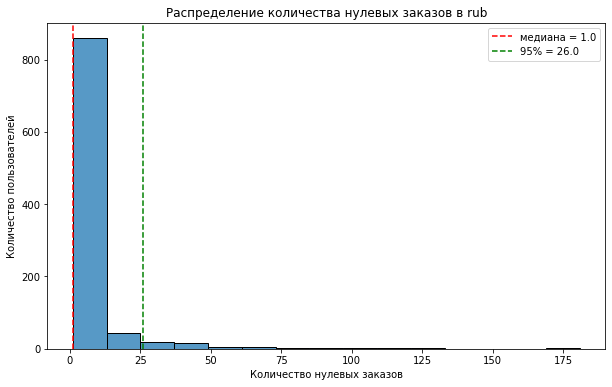

In [28]:
med = df_rub_zero_user.median()
p95 = df_rub_zero_user.quantile(0.95)

plt.figure(figsize=(10, 6))

sns.histplot(df_rub_zero_user, bins=15)
plt.title('Распределение количества нулевых заказов в rub')
plt.xlabel('Количество нулевых заказов')
plt.ylabel('Количество пользователей')
plt.axvline(med, color='red', linestyle='--', label=f'медиана = {med}')
plt.axvline(p95, color='green', linestyle='--', label=f'95% = {p95}')
plt.legend()
plt.grid(False)
plt.show()

Строки с нулевой выручкой в рублевой валюте составляют чуть менее **2%**, такие заказы встречаются у **957** пользователей. В рамках текущего исследования не достаточно данных для выяснения причины появления таких заказов - это могут быть как акционные заказы по нулевой цене, так и технические заказы. На графике распределения нулевых заказов видно, что большинство таких значений у одного пользователя в диапазоне до 26 шт. Значения выше могут являться техническими заказами, но они составляют незначительную долю в данных.

Данные с нулевой выручкой будут оставлены, так как составляют достаточно большую долю заказов, чтобы удалить их и могут отражать реальное пользовательское поведение в связке с рекламными акциями. 

Отберем данные значений выручки по 99-м процентилю.

In [29]:
rub_99_per = df_rub['revenue'].quantile(0.99)
kzt_99_per = df_kzt['revenue'].quantile(0.99)

df_rub = df_rub[df_rub['revenue'] < rub_99_per]
df_kzt = df_kzt[df_kzt['revenue'] < kzt_99_per]

In [30]:
print(f'Осталось {len(df_rub)+len(df_kzt)} строк')
print(round((len(df_rub)+len(df_kzt))/len(df)*100, 2))

Осталось 287490 строк
98.94


После того, как были ограничены экстремальные значения по 99-му процентилю осталось 287 499 строк, осталось 98.94% данных.

In [31]:
df_rub_less_zero = df_rub[df_rub['revenue'] < 0]

print(f'Количество строк с отрицательными значениями: {len(df_rub_less_zero)}, {round(len(df_rub_less_zero) / len(df_rub) * 100, 2)}%')


Количество строк с отрицательными значениями: 381, 0.13%


In [32]:
df_rub_less_zero_device = df_rub_less_zero.groupby('device_type_canonical')['order_id'].count().sort_values(ascending=False)
print(df_rub_less_zero_device)

df_rub_less_zero_user = df_rub_less_zero.groupby('user_id')['order_id'].count().sort_values(ascending=False)
print(df_rub_less_zero_user)

df_rub_less_zero_event = df_rub_less_zero.groupby('event_type_main')['order_id'].count().sort_values(ascending=False)
print(df_rub_less_zero_event)

device_type_canonical
mobile     358
desktop     23
Name: order_id, dtype: int64
user_id
0beb8fc0c0a9ce1    13
efd7b595af23463    10
b54dd0cd81121fc    10
db6d40d98e73a5d     9
44c1c640a242aea     9
                   ..
63797889b4e3938     1
6340d0b890546fa     1
6191b67aadb9231     1
5c7c889566600da     1
ff20aac2834373f     1
Name: order_id, Length: 175, dtype: int64
event_type_main
другое      315
выставки     43
спорт        22
концерты      1
Name: order_id, dtype: int64


Строки с отрицательной выручкой будут удалены, так как они будут искажать дальнейший анализ пользовательского спроса и ключевые метрики исследования. Данные с отрицательной выручкой распределены по разным пользователям, большинство сделаны с ``мобильного приложения`` (**358**) на тип мероприятия ``другое`` (**315**), доля таких записей составляет **0,13%**. 

Удаление отрицательных значений позволит избежать искажения не повлияет на репрезентативность выборки.

In [33]:
df_rub = df_rub[df_rub['revenue'] >= 0]

df_clean = pd.concat([df_rub, df_kzt], ignore_index=False)
df_clean.info()

print(f'Оcталось {len(df_clean)} строк, {round(len(df_clean)/purchases_start*100, 2)}% от первначальной таблицы purchases')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 287109 entries, 0 to 43099
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287109 non-null  int32         
 1   user_id                 287109 non-null  object        
 2   created_dt_msk          287109 non-null  datetime64[ns]
 3   created_ts_msk          287109 non-null  datetime64[ns]
 4   event_id                287109 non-null  int32         
 5   cinema_circuit          287109 non-null  bool          
 6   age_limit               287109 non-null  category      
 7   currency_code           287109 non-null  category      
 8   device_type_canonical   287109 non-null  category      
 9   revenue                 287109 non-null  float32       
 10  service_name            287109 non-null  object        
 11  tickets_count           287109 non-null  int8          
 12  total                   287109 

Из датафрейма убраны выбросы колчественных данных - удалены отрицательные значения, верхний порог ограничен 99м процентилем. После обработки осталось **98.72%** данных от первоначальной таблицы с покупками ``purchases``.

Перейдем к оценке значений в поле ``tickets_count``.

#### tickets_count

In [34]:
print('Данные о поле revenue rub: ')
print(df_rub['tickets_count'].describe())

print('Данные о поле revenue kzt: ')
print(df_kzt['tickets_count'].describe())

Данные о поле revenue rub: 
count    282266.000000
mean          2.740663
std           1.163507
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64
Данные о поле revenue kzt: 
count    4843.000000
mean        2.698121
std         1.093960
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: tickets_count, dtype: float64


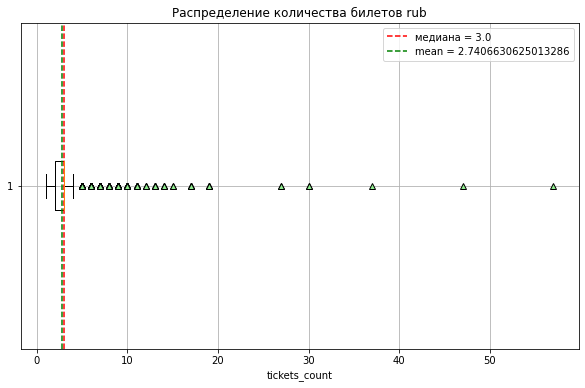

In [35]:
med = df_rub['tickets_count'].quantile(0.5)
mean = df_rub['tickets_count'].mean()

plt.figure(figsize=(10, 6))
plt.boxplot(df_rub['tickets_count'], 
            vert=False,
            flierprops=dict(markerfacecolor='lightgreen', marker='^')
           )
plt.title('Распределение количества билетов rub')
plt.xlabel('tickets_count')
plt.grid(True)
plt.axvline(med, color='red', linestyle='--', label=f'медиана = {med}')
plt.axvline(mean, color='green', linestyle='--', label=f'mean = {mean}')
plt.legend()
plt.show()

In [36]:
ticket_99 = df_rub['tickets_count'].quantile(0.99)
df_tickets_99 = df_rub[df_rub['tickets_count'] > ticket_99]
print(f'Значение 99-процентиля = {ticket_99}')
print(f'Количество выбросов в rub: {len(df_tickets_99)}')


Значение 99-процентиля = 6.0
Количество выбросов в rub: 180


В распределении количества билетов в заказе **kzt** аномалий нет: 
* минимальное значение: 1
* максимальное значение: 6
* медиана 3
* среднее значение: 2.76
* Чаще всего пользователи покупают 2-4 билета

В распределении количества билетов в заказе **rub** есть выбросы: 
* минимальное значение: 1
* максимальное значение: 57
* медиана: 3
* среднее значение: 2.75
* Чаще всего пользователи покупают 2-4 билета
* Выбросы составляют 188 заказов, ~0,06%, это могут быть покупки групповых посещений мероприятий, B2B сегмент, перекупщики.

### Создание новых столбцов

#### ``revenue_rub`` - привести выручку к единой валюте rub с помощью датасета ``final_tickets_tenge_df.csv``

In [37]:
df_final = pd.merge(df_clean, df_convertation, how='left', left_on='created_dt_msk', right_on='data').copy()
display(df_final.head(2))
df_final.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,data,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,False,16,rub,mobile,1521.939941,...,Каменевский регион,Глиногорск,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,100,18.697201,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,False,0,rub,mobile,289.450012,...,Каменевский регион,Глиногорск,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,100,18.341900,kzt


<class 'pandas.core.frame.DataFrame'>
Int64Index: 287109 entries, 0 to 287108
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287109 non-null  int32         
 1   user_id                 287109 non-null  object        
 2   created_dt_msk          287109 non-null  datetime64[ns]
 3   created_ts_msk          287109 non-null  datetime64[ns]
 4   event_id                287109 non-null  int32         
 5   cinema_circuit          287109 non-null  bool          
 6   age_limit               287109 non-null  category      
 7   currency_code           287109 non-null  category      
 8   device_type_canonical   287109 non-null  category      
 9   revenue                 287109 non-null  float32       
 10  service_name            287109 non-null  object        
 11  tickets_count           287109 non-null  int8          
 12  total                   287109

In [38]:
df_final['revenue_rub'] = df_final['revenue'].where(
    df_final['currency_code'] == 'rub', 
    (df_final['revenue'] * df_final['curs']) / df_final['nominal']
).round(2)

In [39]:
df_final = df_final.drop(columns=['data', 'nominal', 'curs', 'cdx'])

In [40]:
df_final['revenue_rub'] = df_final['revenue_rub']
display(df_final.tail(5))

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub
287104,6862648,ffc24188a1d58f2,2024-07-11,2024-07-11 12:39:48,538828,False,12,kzt,mobile,4735.520020,...,концерт,концерты,№2434,Верхоречная область,Серебрянка,163,4348,"Мастерская живого действия ""Юность"" Лтд","наб. Осенняя, д. 376",865.359985
287105,6763294,ffc24188a1d58f2,2024-09-05,2024-09-05 12:07:00,538828,False,12,kzt,mobile,4735.520020,...,концерт,концерты,№2434,Верхоречная область,Серебрянка,163,4348,"Мастерская живого действия ""Юность"" Лтд","наб. Осенняя, д. 376",872.359985
287106,3984021,ffc24188a1d58f2,2024-09-06,2024-09-06 19:20:03,533803,False,16,kzt,mobile,1849.410034,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",343.070007
287107,8493898,ffc4133fbba20f4,2024-06-21,2024-06-21 13:41:39,533803,False,16,kzt,mobile,3698.830078,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",687.210022
287108,8493869,ffc4133fbba20f4,2024-06-21,2024-06-21 14:04:34,533803,False,16,kzt,mobile,3698.830078,...,фестиваль,концерты,№4950,Шанырский регион,Широковка,162,3407,"Арт-кафе ""Речка"" Лимитед","алл. Путейская, д. 548 стр. 7",687.210022


####  ``one_ticket_revenue_rub`` - выручка с продажи одного билета

In [41]:
df_final['one_ticket_revenue_rub'] = round(df_final['revenue_rub'] / df_final['tickets_count'], 2)

####   ``month`` - месяц оформления заказа

In [42]:
df_final['month'] = df_final['created_dt_msk'].dt.month

df_final['month'] = pd.to_numeric(df_final['month'], downcast='integer')

####  ``season`` - информация о сезонности (``лето, осень, зима, весна``)

Применим лямбда-функцию, добавим сезоны ``лето`` и ``осень``, так как данные ограничены датами с 01.06.2024 по 31.10.2024.

In [43]:
df_final['season'] = df_final['month'].apply(lambda x: 'лето' if 6 <= x <= 8 else 'осень')

In [44]:
display(df_final.sample(5))
df_final.info()

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,region_name,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season
222859,6059609,c4729bdeb53fc6d,2024-06-07,2024-06-07 07:57:09,515462,False,18,rub,mobile,1146.010010,...,Серебринская область,Озерчане,62,2173,"Архитектурное бюро ""Совет"" Групп","пр. Веселый, д. 7",1146.010010,229.199997,6,лето
225882,1586098,c7a762e320f0def,2024-07-29,2024-07-29 16:03:59,553518,False,18,rub,mobile,0.000000,...,Каменевский регион,Глиногорск,213,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",0.000000,0.000000,7,лето
206854,1831786,b13ad7486136c8d,2024-09-08,2024-09-08 20:44:14,555432,False,16,rub,mobile,852.650024,...,Североярская область,Озерск,2,1416,"Музей науки ""Спелка"" Инкорпорэйтед","наб. Карбышева, д. 9/7 стр. 3/1",852.650024,284.220001,9,осень
77303,7030790,3a228a5ea08fe73,2024-09-14,2024-09-14 19:01:10,268058,False,12,rub,desktop,176.330002,...,Широковская область,Радужнополье,35,3180,"Академия прикладного искусства ""Полуостров"" Групп","алл. Набережная, д. 129 к. 1",176.330002,58.779999,9,осень
76429,3902502,39e8fb6cd0d2b9a,2024-10-21,2024-10-21 16:10:50,483803,False,12,rub,mobile,29.840000,...,Лугоградская область,Кристалевск,193,2340,"Уличный театр ""Краски"" и партнеры","наб. Речная, д. 4/8 к. 6/1",29.840000,9.950000,10,осень


<class 'pandas.core.frame.DataFrame'>
Int64Index: 287109 entries, 0 to 287108
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                287109 non-null  int32         
 1   user_id                 287109 non-null  object        
 2   created_dt_msk          287109 non-null  datetime64[ns]
 3   created_ts_msk          287109 non-null  datetime64[ns]
 4   event_id                287109 non-null  int32         
 5   cinema_circuit          287109 non-null  bool          
 6   age_limit               287109 non-null  category      
 7   currency_code           287109 non-null  category      
 8   device_type_canonical   287109 non-null  category      
 9   revenue                 287109 non-null  float32       
 10  service_name            287109 non-null  object        
 11  tickets_count           287109 non-null  int8          
 12  total                   287109

#### Результат предобработки данных

* Столбцы, содержащие даты были приведены к типу данных **datetime64**
* Были объединены датафреймы ``df_purchases`` и ``df_events``
* Категориальные столбцы ``device_type_canonical``, ``event_type_description``, ``event_type_main``, ``currency_code`` проверены на неявные дубликаты в данных, столбцы ``region_name`` и ``city_name`` приведены к единому стилю написания, и также проверены на содержание дубликатов.
* Удалены неявные дубликаты по всем признакам, кроме ``order_id`` и ``days_since_prev`` (**40 строк**).
* ``days_since_prev`` пересчитан, с учетом удаленных дубликатов
* Проверены пропуски в поле ``days_since_prev`` - они соответствуют первому заказу пользователя.
* Количественные данные в ключевом поле ``revenue`` ограничены 99-м процентилем, удалены отрицательные значения.
* В данных встречаются нулевые значения выручки, в kzt таких строк 0.12% (6 строк), в rub таких данных 1,93%. Нулевые значения оставлены.
* В поле ``tickets_count``в распределении количества билетов в заказе ``kzt`` аномалий нет, в ``rub`` есть выбросы, их количество 0,06%, данные оставлены, это могут быть покупки билетов групповых посещений мероприятий, B2B сегмент, перекупщики.
* Добавлены новые столбцы:
    * ``revenue_rub`` - выручка в валюте rub
    * ``one_ticket_revenue_rub`` - выручка с продажи одного билета
    * ``month`` - месяц оформления заказа
    * ``season`` - информация о сезонности (лето, осень - данные ограничены этими сезонами)
    

После предобработки данных осталось **287 109** строк, **98.72%** от первоначального датафрейма ``df_purchases``.

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения



#### Изменение количества заказов по месяцам

,month,order_id,change
0,6,33866,NaN
1,7,40357,19.17
2,8,44520,10.32
3,9,69229,55.50
4,10,99137,43.20


,month,user_id,change
0,6,6192,NaN
1,7,6534,5.52
2,8,7304,11.78
3,9,9341,27.89
4,10,11439,22.46


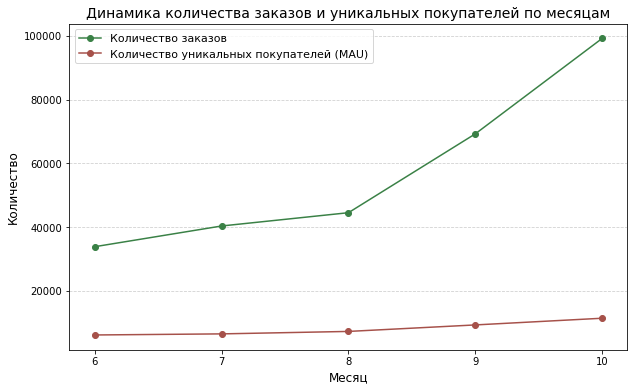

In [45]:
orders_count = pd.pivot_table(df_final,
                    index = 'month',
                    values = 'order_id',
                    aggfunc = 'count').reset_index()

orders_count['change'] = round(orders_count['order_id'].pct_change() * 100, 2)

mau = pd.pivot_table(df_final,
                    index = 'month',
                    values = 'user_id',
                    aggfunc = 'nunique').reset_index()

mau['change'] = round(mau['user_id'].pct_change() * 100, 2)

display(orders_count)
display(mau)

fig, ax = plt.subplots(figsize=(10, 6))

orders_count.plot.line(
    x='month', 
    y='order_id', 
    ax=ax, 
    marker='o', 
    color='#3A8146',
    label='Количество заказов'
)

mau.plot.line(
    x='month', 
    y='user_id', 
    ax=ax, 
    marker='o', 
    color='#A6514A',
    label='Количество уникальных покупателей (MAU)'
)

ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)
ax.set_xticks(orders_count['month'])
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

ax.legend(fontsize=11)
plt.title('Динамика количества заказов и уникальных покупателей по месяцам', fontsize=14)

plt.show()


Месячная динамика количества заказов показывает рост.
Минимальное значение составило **33 866** в июне, максимальное **99 140** в октябре. 
От августа к сентябрю показатель вырос на **55.5%**.

Количество уникальных покупателей также ежемесячно показывает рост. 
Минимальное значение составило **6 192** покупателя в июней, максимальное **11 439** покупателей в октябре.
Самый большой прирост составил **27.89%** от августа к сентябрю.

Рост числа заказов выше, чем рост количества уникальных покупателей, это свидетельствует о том, что начиная с сентября пользователи сервиса чаще делают заказы, рост обеспечивается не только расширением аудитории, но и увеличением активности пользователей.

#### Динамика количества заказов по типу мероприятия ``event_type_main``

С помощью сводной таблицы сгруппируем данные о количестве заказов по типу мероприятия в разрезе времени года, рассчитаем % соотношение мероприятий, а также процентную разницу в количестве заказов летом и осенью.

In [46]:
event_type_count_seasson = pd.pivot_table(df_final, 
                    index = 'event_type_main',
                    columns = 'season',
                    values = 'order_id',
                    aggfunc = 'count').reset_index()
event_type_count_seasson.columns.name = None
total_summer = event_type_count_seasson['лето'].sum()
total_autumn = event_type_count_seasson['осень'].sum()

event_type_count_seasson['лето, %'] = round(event_type_count_seasson['лето'] / total_summer * 100, 2)
event_type_count_seasson['осень, %'] = round(event_type_count_seasson['осень'] / total_autumn * 100, 2)
event_type_count_seasson['разница, %'] = (event_type_count_seasson['осень, %'] - event_type_count_seasson['лето, %'])

event_type_count_seasson = event_type_count_seasson[['event_type_main', 'лето', 'лето, %', 'осень', 'осень, %', 'разница, %']]
event_type_count_seasson = event_type_count_seasson.rename(columns={'event_type_main': 'тип мероприятия', 'лето': 'кол-во лето', 'осень': 'кол-во осень'})

event_type_count_seasson = event_type_count_seasson.sort_values(by='кол-во осень', ascending=False)

print('Количество заказов летом и осенью в разрезе типа мероприятия:')
display(event_type_count_seasson)


Количество заказов летом и осенью в разрезе типа мероприятия:


,тип мероприятия,кол-во лето,"лето, %",кол-во осень,"осень, %","разница, %"
2,концерты,50565,42.58,62684,37.23,-5.35
5,театр,23943,20.16,42733,25.38,5.22
1,другое,32206,27.12,33071,19.64,-7.48
3,спорт,3003,2.53,18862,11.20,8.67
4,стендап,6346,5.34,6923,4.11,-1.23
0,выставки,2407,2.03,2402,1.43,-0.60
6,ёлки,273,0.23,1691,1.00,0.77


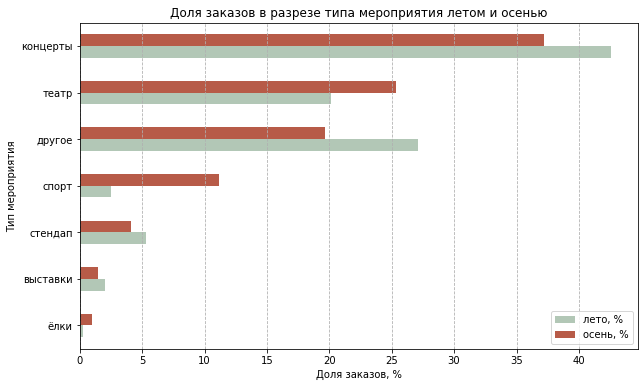

In [47]:
event_type_count_seasson.sort_values(by='кол-во осень', ascending=True).plot.barh(
    x='тип мероприятия', 
    y=['лето, %', 'осень, %'], 
    color={"лето, %": "#b2c7b6", "осень, %": "#b75b48"}, 
    figsize=(10,6))

plt.grid(axis='x', linestyle='--')

plt.xlabel('Доля заказов, %')
plt.ylabel('Тип мероприятия')
plt.title('Доля заказов в разрезе типа мероприятия летом и осенью')

plt.show()

Большую часть мероприятий составляет категория ``концерты``:
* летом **42.58%**
* осенью **37.23%** - **спад на 5.3%**

На втором месте категория ``театр``:
* летом 20.16%
* осенью 25.38% - **рост на 5.2%**

На третьем месте категория ``другое``:
* летом 27.12%
* осенью 19.64% - **спад на 7.5%**

Осенью значительный рост показывают ``спортивные мероприятия``, рост в абсолютном соотношении **15 859** заказов, в относительном **8.7%**.

Категории ``стендап`` и ``выставки`` не показывают значительного изменения в пользовательском поведении (изменения от сезона к сезону ~1%).
``Ёлки``, несмотря на прирост в абсолюном значении (+ 1 418 заказов), в относительном выражении составляют не более 1% от всех заказов. Эта категория является сезонной, большую часть мероприятий ``ёлки`` проводят в декабре-январе.

*Также стоит учитывать, что осень в данных ограничена 2 месяцами, поэтому полный анализ стоит провести после закрытия ноября, однако динамика на изменение пользовательского поведения видна и в рамках текущего исследования.*

#### Динамика количества заказов по типу устройства ``device_type_canonical``

In [48]:
device_count = pd.pivot_table(
                    df_final, 
                    index = 'device_type_canonical',
                    columns = 'season',
                    values = 'order_id',
                    aggfunc = 'count').reset_index()
device_count.columns.name = None

device_count = device_count.rename(columns={'device_type_canonical': 'тип устройства', 'лето': 'кол-во лето', 'осень': 'кол-во осень'})

device_count['лето, %'] = round(device_count['кол-во лето'] / total_summer * 100, 2)
device_count['осень, %'] = round(device_count['кол-во осень'] / total_autumn * 100, 2)
device_count['разница, %'] = device_count['осень, %']-device_count['лето, %']

device_count = device_count[['тип устройства', 'кол-во лето', 'лето, %', 'кол-во осень', 'осень, %', 'разница, %']]

device_count = device_count.sort_values(by='кол-во осень', ascending=False)

print('Количество заказов летом и осенью в разрезе типа устройства:')
display(device_count)

Количество заказов летом и осенью в разрезе типа устройства:


,тип устройства,кол-во лето,"лето, %",кол-во осень,"осень, %","разница, %"
1,mobile,95783,80.66,134081,79.64,-1.02
0,desktop,22960,19.34,34285,20.36,1.02


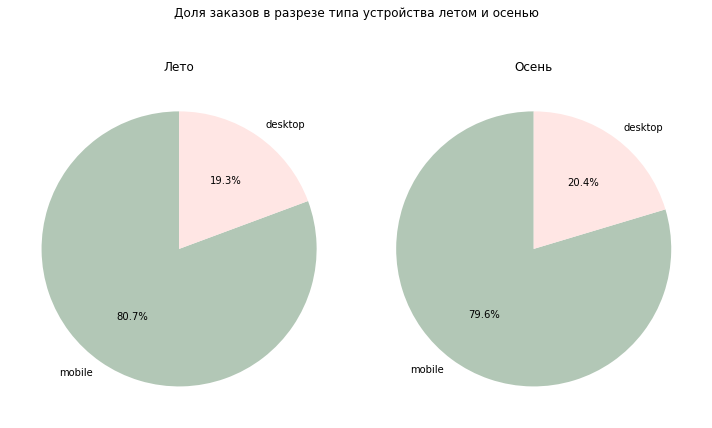

In [49]:
plt.figure(figsize=(10, 7))

plt.subplot(1, 2, 1)
plt.pie(
    device_count["лето, %"],
    labels=device_count["тип устройства"],
    autopct="%1.1f%%",
    startangle=90,
    colors=['#b2c7b6', '#FFE6E4']
)
plt.title('Лето')

plt.subplot(1, 2, 2)
plt.pie(
    device_count["осень, %"],
    labels=device_count["тип устройства"],
    autopct="%1.1f%%",
    startangle=90,
    colors=['#b2c7b6', '#FFE6E4']
)
plt.title('Осень')

plt.tight_layout()
plt.suptitle('Доля заказов в разрезе типа устройства летом и осенью')
plt.show()

Более половины пользователей пользуются ``мобильными устройствами``, их процент составляет **~80%**, от лета к осени изменение незначительно, разница составила 1 процентный пункт.

#### Динамика количества заказов по категорию мероприятия по возрастному рейтингу ``age_limit``

In [50]:
age_limit_count = pd.pivot_table(df_final, 
                              index='age_limit', 
                              columns = 'season',
                              values = 'order_id',
                              aggfunc = 'count').reset_index()
age_limit_count.columns.name = None

age_limit_count['лето, %'] = round(age_limit_count['лето'] / total_summer * 100, 2)
age_limit_count['осень, %'] = round(age_limit_count['осень'] / total_autumn * 100, 2)
age_limit_count['разница, %'] = age_limit_count['осень, %'] - age_limit_count['лето, %']

age_limit_count = age_limit_count.rename(columns={'лето': 'кол-во лето', 'осень': 'кол-во осень'})
age_limit_count = age_limit_count[['age_limit', 'кол-во лето', 'лето, %', 'кол-во осень', 'осень, %', 'разница, %']]

print('Количество заказов летом и осенью в разрезе возрастного ограничения мероприятия:')
display(age_limit_count)

Количество заказов летом и осенью в разрезе возрастного ограничения мероприятия:


,age_limit,кол-во лето,"лето, %",кол-во осень,"осень, %","разница, %"
0,0,21272,17.91,39708,23.58,5.67
1,6,21664,18.24,29677,17.63,-0.61
2,12,24229,20.40,37206,22.10,1.70
3,16,33755,28.43,44209,26.26,-2.17
4,18,17823,15.01,17566,10.43,-4.58


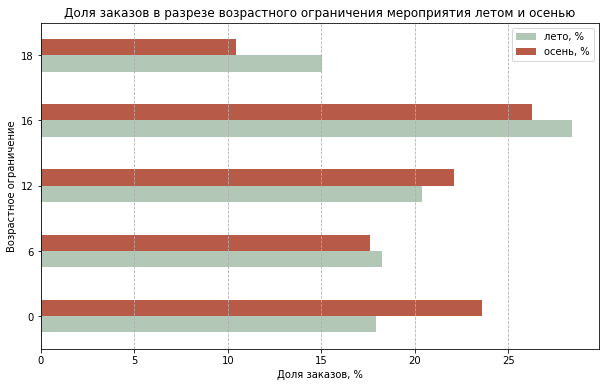

In [51]:
age_limit_count.plot.barh(x='age_limit', 
                          y = ['лето, %', 'осень, %'], 
                          color={"лето, %": "#b2c7b6", "осень, %": "#b75b48"}, 
                          figsize=(10,6))

plt.grid(axis='x', linestyle='--')

plt.xlabel('Доля заказов, %')
plt.ylabel('Возрастное ограничение')
plt.title('Доля заказов в разрезе возрастного ограничения мероприятия летом и осенью')

plt.show()

Наибольшая доля пользователей покупают билеты на мероприятия ``16+``:
* летом **28.4%**
* осенью **26.3%**

Меньше всего приобритают билеты на мероприятия ``18+``:
* летом **15%**
* осенью **10.4%** (спад на 4.6 процентных пункта)

Это может может говорить о том, что пользователи сервиса предпочитают более семейные мероприятия, либо мероприятия ``18+`` представлены в меньшем количестве на сервисе, ориентация на более массовый/семейный сегмент. 

С началом осени заметен рост спроса на события с возрастным ограничением ``0+`` (**+5.7%**) и `` 12+``(**+1.7%**), они составляют **22-23%** от продаж на все мероприятия.

Категория ``6+`` держится на уровне **17-18%**, с началом осени незначительно снизилась (менее чем на 1%).

#### Изменение выручки с продажи одного билета для осеннего и летнего периодов в зависимости от типа мероприятия (event_type_main).

Для каждого типа мероприятия рассчитать среднее значение выручки с одного билета, найти относительное изменение осенних и летних значений.

In [52]:
avg_ticket_revenue = pd.pivot_table(
                    df_final, 
                    index = 'event_type_main',
                    columns = 'season',
                    values = ['revenue_rub', 'tickets_count'],
                    aggfunc = 'sum').reset_index()

avg_ticket_revenue['avg_summer'] = avg_ticket_revenue[('revenue_rub', 'лето')] / avg_ticket_revenue[('tickets_count', 'лето')]
avg_ticket_revenue['avg_autumn'] = avg_ticket_revenue[('revenue_rub', 'осень')] / avg_ticket_revenue[('tickets_count', 'осень')]


avg_ticket_revenue['разница, %'] = round(avg_ticket_revenue['avg_autumn']/avg_ticket_revenue['avg_summer']*100-100, 2)
avg_ticket_revenue = avg_ticket_revenue.sort_values(by='avg_autumn', ascending=False)

avg_ticket_revenue = avg_ticket_revenue[['event_type_main', 'avg_summer', 'avg_autumn', 'разница, %']]

print('Средняя выручка с билета в разрезе типа мероприятия летом и осенью:')
display(avg_ticket_revenue)

Средняя выручка с билета в разрезе типа мероприятия летом и осенью:


,event_type_main,avg_summer,avg_autumn,"разница, %"
season,,,,
2,концерты,299.391389,269.163270,-10.10
4,стендап,215.220902,228.673556,6.25
6,ёлки,263.499327,217.969601,-17.28
5,театр,211.352595,176.355111,-16.56
0,выставки,89.531488,93.462299,4.39
1,другое,82.667337,82.510633,-0.19
3,спорт,50.691186,49.851637,-1.66


In [53]:
mean_summer = round(
    df_final[df_final['season']=='лето']['revenue'].sum() 
    / df_final[df_final['season']=='лето']['tickets_count'].sum(),
    2)
mean_autumn = round(
    df_final[df_final['season']=='осень']['revenue'].sum() 
    / df_final[df_final['season']=='осень']['tickets_count'].sum(), 
    2)

print(f'Среднее значение выручки с билета летом: {mean_summer}, осенью: {mean_autumn}')
print(f'Разница: {(mean_autumn/mean_summer-1):.2%}')

Среднее значение выручки с билета летом: 251.54, осенью: 181.48
Разница: -27.85%


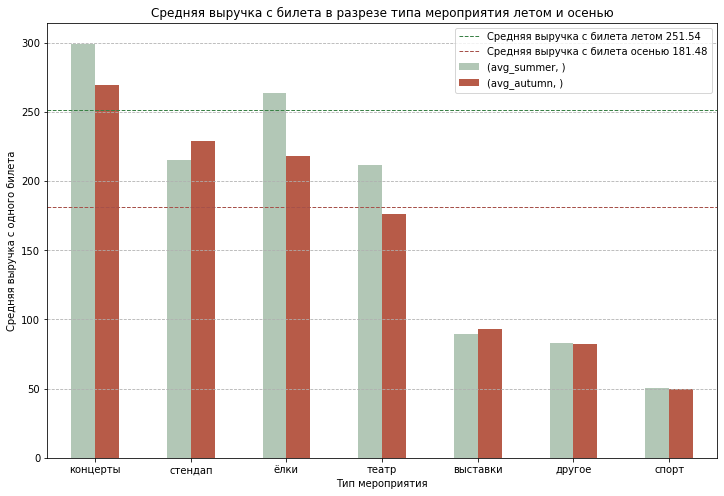

In [54]:
avg_ticket_revenue.plot.bar(x='event_type_main', 
                            y=[('avg_summer', ''), ('avg_autumn', '')], 
                            figsize=(12, 8),
                            color={('avg_summer', ''): "#b2c7b6", ('avg_autumn', ''): "#b75b48"})

plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=0)

plt.axhline(mean_summer, linestyle='--', linewidth = 1, color='#3A8146', label=f'Средняя выручка с билета летом {mean_summer}')
plt.axhline(mean_autumn, linestyle='--', linewidth = 1, color='#A6514A', label=f'Средняя выручка с билета осенью {mean_autumn}')

plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка с одного билета')
plt.title('Средняя выручка с билета в разрезе типа мероприятия летом и осенью')

plt.legend()
plt.show()

Самую большую среднюю выручку с билета стабильно обеспечивают ``концерты``:
* летом: **299.4 руб.**
* осенью: **269 руб.** (-10.1%)

На втором месте по значению средней выручки с билета ``стендап``:
* летом **215 руб.**
* осенью **228 руб.** (+6.25%)

Выручка с продажи одного билета осенью снижается по всем категориям мероприятий, кроме ``выставки`` и ``стендап`` (рост на **~5%**). Однако, доля этих мероприятий составляет **5.54%** от всех продаж. 

Категории ``спорт`` и ``другое`` показывают минимальное изменение среднего чека,  цены на эти мероприятия самые низкие и не зависят от сезона лето/осень.

Категория ``ёлки``, несмотря на малую долю в количестве продаж, потенциально прибыльная категория с одиним из самых высоких средних чеков **217.8 руб.** осенью. Так как сезон этих мероприятий - декабрь-январь, стоит обратить внимание на сегмент накануне начала сезона (предпродажи билетов, маркетинговая активность по направлению).

Осенью средний чек **упал на 27.85%**, при общем увеличении количества заказов и покупателей, это может говорить о том, что осенью увеличивается спрос на менее дорогие, массовые мероприятия. 


#### Вывод анализа распределения заказов по сегментам и их сезонные изменения

*В исследуемых данных сезон "осень" ограничен 2 месяцами - **с 01.09.24 по 31.10.24**, поэтому полный анализ стоит провести после закрытия ноября, однако динамика на изменение пользовательского поведения видна и в рамках текущего исследования.*

* С наступлением осени начинается рост количества заказов и количества покупателей. При этом рост числа заказов превышает рост количества покупателей, начиная с сентября пользователи сервиса чаще делают заказы, рост выручки обеспечивается не только расширением аудитории, но и увеличением активности пользователей.


* От августа к сентябрю количество заказов выросло на **55.5%** (с **44 522** в августе до **69 231** в сентябре), это самый заметный рост, что подтверждает сезонность спроса и совпадает с концом сезона отпусков и началом учебного года, а также началом спортивного и театрального сезонов.


* Большую часть продаж составляют ``концерты`` 37.2%, несмотря на **спад** по сравнению с летним периодом **на 5.3 п.п.**


* Осенью значительный рост количества заказов показывают ``спортивные мероприятия`` **рост на 8.7 п.п.** (в абсолютном значении с **3003** летом до **18 862** осенью) и категория ``театр`` **рост на 5.2 п.п.** (в абсолютном значении с **23 943** летом до **42 735** осенью)


* Более половины пользователей пользуются мобильными устройствами **~80%**, осенью изменение незначительно, разница **1 п.п.**. Немного увеличилось число пользователей стационарных устройств.


* С началом осени заметен рост спроса на события с возрастным ограничением ``0+`` (**+5.7 п.п.**) и `` 12+``(**+1.7 п.п.**), они составляют **22-23%** от продаж на все мероприятия. Категория ``6+`` держится на уровне **17-18%**, зависимость от сезонности не наблюдается. Увеличивается спрос на семейные мероприятия.


* Выручка с продажи одного билета осенью снижается по всем категориям мероприятий, кроме ``выставки`` и ``стендап`` (**рост на ~5%**). 


* Категории ``спорт`` и ``другое`` показывают минимальное изменение среднего чека, цены на эти мероприятия самые низкие и не зависят от сезона лето/осень.


* Категория ``ёлки``, несмотря на малую долю в количестве продаж, является категорией с одиним из самых высоких средних чеков **217 руб.** осенью. *В предновогодний период сервису может быть полезно усиливать продвижение подобных мероприятий и заранее запускать рекомендации для семейной аудитори, так как сезон этих мероприятий - декабрь-январь, стоит обратить внимание на сегмент накануне начала сезона (предпродажи билетов, маркетинговая активность по направлению).*


* Осенью средний чек упал на **27.85%**, при общем увеличении количества заказов и покупателей, это может говорить о том, что осенью увеличивается спрос на более дешевые, массовые мероприятия. 


* Осенью заметна более интенсивная динамика активности пользователей. Это согласуется с окончанием летних отпусков и наступлением осени (начало театрального сезона, спортивных турниров): 
    * начало учебного года - увеличение семейных и школьных мероприятий ``12+``
    * ухудшение погоды - переход с фестивалей и опер-эиров на мероприятия в закрытых помещениях, таких как стендап и выставки
    * также летом люди чаще уезжают из города, тогда как осенью чаще выбирают мероприятия в городе.

### Анализ осенней активности пользователей

* Динамика показателей по дням (сводная таблица + визуализация (линейный график)):
    * общее число заказов
    * количество активных пользователей (DAU)
    * среднее число заказов на 1 пользователя
    * средняя стоимость одного билета

Отфильтруем данные, оставив только ``осень``.

Созададим сводную таблицу с показателями.

In [55]:
autumn_df = df_final.query('season == "осень"')
autumn_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 168366 entries, 2 to 287106
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                168366 non-null  int32         
 1   user_id                 168366 non-null  object        
 2   created_dt_msk          168366 non-null  datetime64[ns]
 3   created_ts_msk          168366 non-null  datetime64[ns]
 4   event_id                168366 non-null  int32         
 5   cinema_circuit          168366 non-null  bool          
 6   age_limit               168366 non-null  category      
 7   currency_code           168366 non-null  category      
 8   device_type_canonical   168366 non-null  category      
 9   revenue                 168366 non-null  float32       
 10  service_name            168366 non-null  object        
 11  tickets_count           168366 non-null  int8          
 12  total                   168366

In [56]:
autumn_pivot = pd.pivot_table(autumn_df, 
                              index = 'created_dt_msk', 
                              values = ['order_id', 'user_id', 'one_ticket_revenue_rub'], 
                              aggfunc={'order_id': 'count', 'user_id': 'nunique', 'one_ticket_revenue_rub': 'mean'}).reset_index()

autumn_pivot['orders_avg'] = round(autumn_pivot['order_id']/autumn_pivot['user_id'], 2)

autumn_pivot = autumn_pivot.rename(columns={'created_dt_msk': 'date', 'one_ticket_revenue_rub': 'revenue_avg', 'order_id': 'order_count', 'user_id': 'dau'})
autumn_pivot = autumn_pivot[['date', 'order_count', 'dau', 'orders_avg', 'revenue_avg']]

display(autumn_pivot)

,date,order_count,dau,orders_avg,revenue_avg
0,2024-09-01,1327,564,2.35,200.168900
1,2024-09-02,1376,573,2.40,190.015717
2,2024-09-03,5092,777,6.55,80.429688
3,2024-09-04,1759,683,2.58,179.100311
4,2024-09-05,1941,738,2.63,189.804337
...,...,...,...,...,...
56,2024-10-27,2844,1032,2.76,187.300217
57,2024-10-28,2837,985,2.88,170.715897
58,2024-10-29,2831,998,2.84,177.624496
59,2024-10-30,2925,1039,2.82,182.916885


#### Визуализация общего числа заказов и DAU

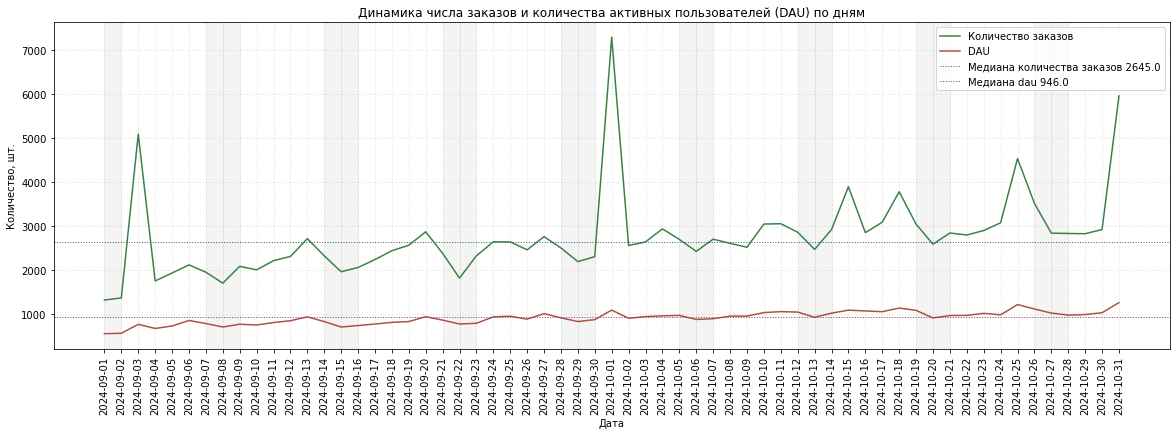

In [57]:
med_order_count = autumn_pivot['order_count'].median()
med_dau = autumn_pivot['dau'].median()

dates = pd.date_range(start=autumn_pivot['date'].min(), end=autumn_pivot['date'].max(), freq='D')

fig, ax = plt.subplots(figsize=(20, 6))

# выделим на графие выходные дни
for day in dates:
    if day.weekday() in [5, 6]: 
        ax.axvspan(day, day + pd.Timedelta(days=1), color='#EAEAEA', alpha=0.5)

ax.plot(dates, autumn_pivot['order_count'], linestyle='-', color='#3A8146', label='Количество заказов')

ax.plot(dates, autumn_pivot['dau'], linestyle='-', color='#A6514A', label='DAU')

plt.axhline(med_order_count, linestyle=':', linewidth = 1, color='#2F6067', label=f'Медиана количества заказов {med_order_count}')
plt.axhline(med_dau, linestyle=':', linewidth = 1, color='#883D63', label=f'Медиана dau {med_dau}')

ax.legend() 
plt.xticks(dates, rotation=90, fontsize=10)
plt.grid(linestyle='--', linewidth = 1, alpha=0.2)

plt.xlabel('Дата')
plt.ylabel('Количество, шт.')
plt.title('Динамика числа заказов и количества активных пользователей (DAU) по дням')

plt.show()

Количество заказов и количество уникальных пользователей показывают схожую динамику. 

Минимальные значения приходятся на **01.09.24**:
* Количество заказов: **1 327**
* Количество пользователей: **564**

Максимальные значения:
* Количество заказов: **01.10.24 7 288**
* Количество пользователей: **31.10.24 1270**

Также наблюдаются сильные скачки роста количества заказов **03.09.24 и 31.10.24**

В динамике присутствует цикличность - спады пользовательсокой активности приходятся на выходные дни, по воскресеньям количество оформленных заказов уменьшается, в пятницу наблюдается рост. 


#### Визуализация среднего количества заказов на одного пользователя

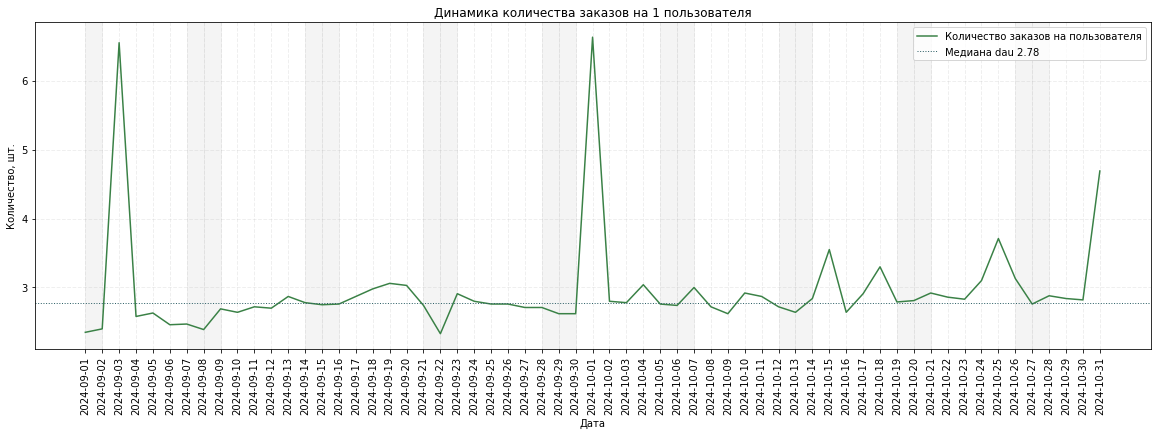

In [58]:
med_orders_avg = autumn_pivot['orders_avg'].median()

fig, ax = plt.subplots(figsize=(20, 6))

for day in dates:
    if day.weekday() in [5, 6]: 
        ax.axvspan(day, day + pd.Timedelta(days=1), color='#EAEAEA', alpha=0.5)

ax.plot(dates, autumn_pivot['orders_avg'], linestyle='-', color='#3A8146', label='Количество заказов на пользователя')
plt.axhline(med_orders_avg, linestyle=':', linewidth = 1, color='#2F6067', label=f'Медиана dau {med_orders_avg}')
ax.legend() 
plt.xticks(dates, rotation=90, fontsize=10)
plt.grid(linestyle='--', linewidth = 1, alpha=0.2)

plt.xlabel('Дата')
plt.ylabel('Количество, шт.')
plt.title('Динамика количества заказов на 1 пользователя')

plt.show()

На графике Динамики количества заказов на 1 пользователя наблюдаются 2 пика роста **03.09.24 (6.5)** и **01.10.24 (6.6)**.

Также видна цикличность динамики - спады в воскресенье, рост во второй половине недели.

#### Визуализация средней стоимости одного билета

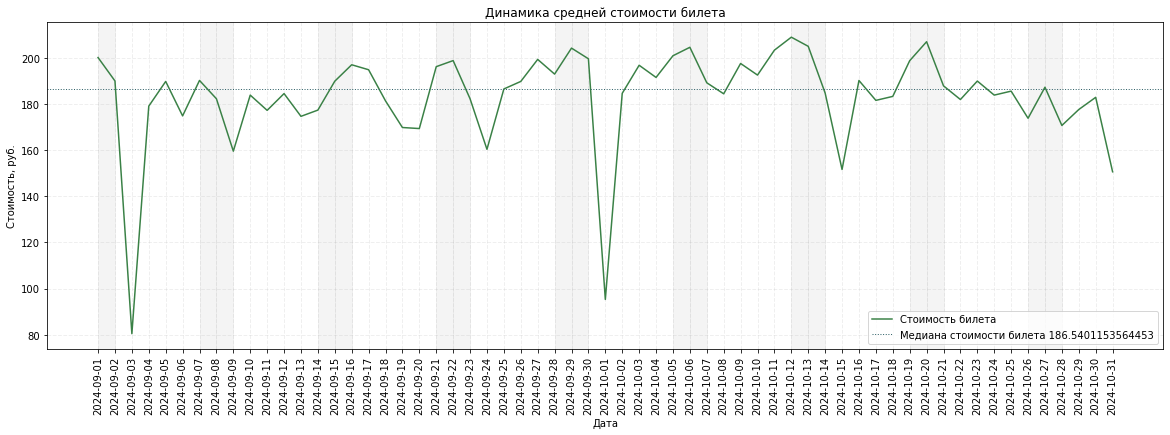

In [59]:
med_revenue_avg = autumn_pivot['revenue_avg'].median()

fig, ax = plt.subplots(figsize=(20, 6))

for day in dates:
    if day.weekday() in [5, 6]: 
        ax.axvspan(day, day + pd.Timedelta(days=1), color='#EAEAEA', alpha=0.5)

ax.plot(dates, autumn_pivot['revenue_avg'], linestyle='-', color='#3A8146', label='Стоимость билета')
plt.axhline(med_revenue_avg, linestyle=':', linewidth = 1, color='#2F6067', label=f'Медиана стоимости билета {med_revenue_avg}')
ax.legend() 
plt.xticks(dates, rotation=90, fontsize=10)
plt.grid(linestyle='--', linewidth = 1, alpha=0.2)

plt.xlabel('Дата')
plt.ylabel('Стоимость, руб.')
plt.title('Динамика средней стоимости билета')

plt.show()

На графике Динамики средней стоимости билета видны резкие спады **03.09.24 и 01.10.24 (средний чек менее 100 руб.)**, которые совпадают с пиками покупательской активности. Эти даты являются первым вторником месяца, вероятно в эти дни проходит регулярная маркетинговая активность.

Возможно, в эти дни проходили маркетинговые акции, или стартовали продажи билетов на массовые мероприятия с невысокой стоимостью.



#### Недельная цикличность пользовательской активности

* выделить день недели и сравнить пользовательскую активность в будние дни и выходные

Сгруппируем данные по дням недели (0 - понедельник, 6 - воскресенье), агрегация по медиане, так как в данных есть сильные выбросы активности 03.09 и 01.10.



In [60]:
autumn_pivot['day_week'] = autumn_pivot['date'].dt.weekday

autumn_pivot_week_day = autumn_pivot.groupby('day_week')[['order_count', 'dau', 'orders_avg', 'revenue_avg']].median().reset_index()
autumn_pivot_week_day['day_week_name'] = pd.cut(autumn_pivot_week_day['day_week'], 
                                                bins=[-1, 0, 1, 2, 3, 4, 5, 6], 
                                                labels=['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс'])

autumn_pivot_week_day = autumn_pivot_week_day[['day_week_name', 'order_count', 'dau', 'orders_avg', 'revenue_avg']]
display(autumn_pivot_week_day)
display(autumn_pivot_week_day.sort_values(by='order_count', ascending=False))

,day_week_name,order_count,dau,orders_avg,revenue_avg
0,пн,2331.0,883.0,2.84,187.897095
1,вт,2802.0,962.0,2.86,177.624496
2,ср,2563.0,960.0,2.76,184.652145
3,чт,2645.0,952.0,2.91,184.536728
4,пт,2908.0,993.5,2.95,184.461884
5,сб,2605.0,951.5,2.75,194.597778
6,вс,2198.0,840.0,2.64,200.168900


,day_week_name,order_count,dau,orders_avg,revenue_avg
4,пт,2908.0,993.5,2.95,184.461884
1,вт,2802.0,962.0,2.86,177.624496
3,чт,2645.0,952.0,2.91,184.536728
5,сб,2605.0,951.5,2.75,194.597778
2,ср,2563.0,960.0,2.76,184.652145
0,пн,2331.0,883.0,2.84,187.897095
6,вс,2198.0,840.0,2.64,200.168900


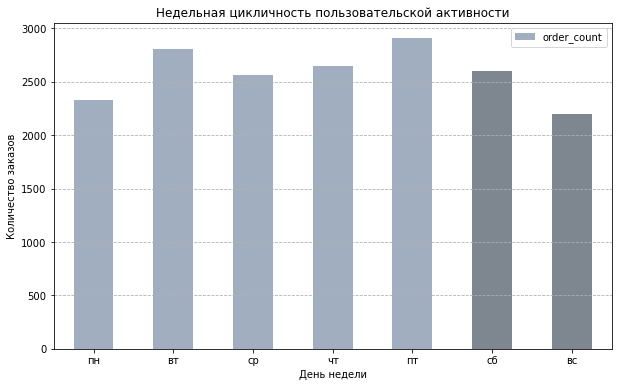

In [61]:
day_colors = {
    'пн': '#A0AEC0', 'вт': '#A0AEC0', 'ср': '#A0AEC0', 'чт': '#A0AEC0', 'пт': '#A0AEC0',
    'сб': '#7E8690', 'вс': '#7E8690'
}

colors_list = autumn_pivot_week_day['day_week_name'].map(day_colors)

autumn_pivot_week_day.plot.bar(x='day_week_name', 
                            y='order_count', 
                            figsize=(10, 6), 
                            color = colors_list)

plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=0)


plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.title('Недельная цикличность пользовательской активности')

plt.legend()
plt.show()

#### Промежуточный вывод о пользовательской активности и недельной цикличности

Пользователи активнее всего оформляют покупки в пятницу и вторник, меньше всего в понедельники и воскресенье. 

В пятницу пользователи проявляют максимальную активность - среднее количество заказов  **2 908**, уникальных покупателей **993**, среднее количество билетов в заказе **2.95**.
Самая низкая активность в воскресенье, при самом высоком среднем чеке **200 руб.**

На графике Динамики средней стоимости билета видны резкие спады **03.09.24 и 01.10.24 (средний чек менее 100 руб.)**, которые совпадают с пиками покупательской активности. Эти даты являются первым вторником месяца, вероятно в эти дни проходит регулярная маркетинговая активность.


### Популярные события и партнёры (абсолютные и относительные значения, за период осень 2024г)

#### Распределение событий по регионам

* Для каждого региона посчитаем уникальное количество мероприятий и общее число заказов.

In [62]:
region_pivot = pd.pivot_table(autumn_df, 
                              index='region_name', 
                              values=['order_id', 'event_id'], 
                              aggfunc={'order_id': 'count', 'event_id': 'nunique'}).reset_index()

total_orders = autumn_df['order_id'].count()
total_events = autumn_df['event_id'].nunique()

region_pivot['order_share'] = round(region_pivot['order_id']/total_orders*100, 2)
region_pivot['event_share'] = round(region_pivot['event_id']/total_events*100, 2)

region_pivot = region_pivot[['region_name', 'event_id', 'event_share', 'order_id', 'order_share']]

region_pivot = region_pivot.sort_values(by='order_share', ascending=False)
display(region_pivot)

,region_name,event_id,event_share,order_id,order_share
23,Каменевский регион,3910,24.68,46682,27.73
59,Североярская область,2611,16.48,20704,12.30
41,Медовская область,368,2.32,12043,7.15
75,Широковская область,796,5.03,8648,5.14
44,Озернинский край,296,1.87,7480,4.44
...,...,...,...,...,...
32,Крутоводский регион,5,0.03,14,0.01
68,Тихогорская область,10,0.06,19,0.01
65,Сосноводолинская область,1,0.01,9,0.01
47,Островогорский округ,4,0.03,18,0.01


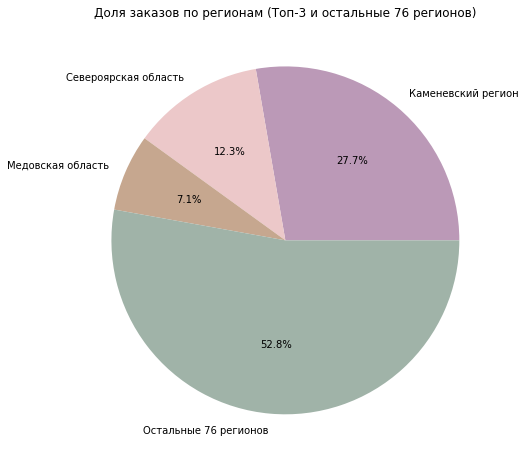

In [63]:
top3 = region_pivot.head(3).copy()

others_orders = region_pivot.iloc[3:]['order_id'].sum()
others_share = region_pivot.iloc[3:]['order_share'].sum()

others_row = pd.DataFrame([{
    'region_name': 'Остальные 76 регионов',
    'order_id': others_orders,
    'order_share': others_share
}])

pie_data = pd.concat([top3, others_row], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(pie_data['order_share'], 
    labels = pie_data['region_name'], 
    autopct='%1.1f%%',
    colors=['#bb99b7', '#ecc8c9', '#c6a78f', '#a0b3a8']
)

plt.title('Доля заказов по регионам (Топ-3 и остальные 76 регионов)')
plt.show()

Наибольшее разнообразие мероприятий предлагается в:
1. ``Каменевском регионе`` **24.7%** от всех событий, продажа билетов составляет **27.7%**
2. ``Североярской области`` **16.5%** от всех событий, продажа билетов составляет **12.3%**

Остальные доли мероприятий распределены по 76 регионам от 7.15% до 0.01% всех продаж.

В ``Североярской области`` доля продаж составляет меньшую долю, чем предлагаемое разнообразие мероприятий, возможно стоит отдельно провести иследование и рассмотреть возможности увеличения конверсии продаж.

``Медовская область`` занимает третье место по объему продаж **7.15%**, при небольшой доле предлагаемых мероприятий **2.32%**. В области виден высокий спрос на мероприятия, стоит рассмотреть возможность расширения 'ассортимента' билетов.

#### Распределение событий по партнерам 

* Для каждого билетного партнёра ``service_name`` посчитайть общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Выделить на наиболее активных партнеров и и общее распределение данных между категориями.

In [64]:
service_name_pivot = pd.pivot_table(autumn_df, 
                              index='service_name', 
                              values=['order_id', 'event_id', 'revenue_rub', 'tickets_count'], 
                              aggfunc={'order_id': 'count', 
                                       'event_id': 'nunique', 
                                       'revenue_rub': 'sum', 
                                       'tickets_count': 'sum'}
                                 ).reset_index()

total_revenue = autumn_df['revenue_rub'].sum()

service_name_pivot['order_share'] = round(service_name_pivot['order_id']/total_orders*100, 2)
service_name_pivot['event_share'] = round(service_name_pivot['event_id']/total_events*100, 2)
service_name_pivot['revenue_share'] = round(service_name_pivot['revenue_rub']/total_revenue*100, 2)

service_name_pivot = service_name_pivot[['service_name', 'event_id', 'event_share', 'order_id', 'order_share', 'revenue_rub', 'revenue_share', 'tickets_count']]

service_name_pivot = service_name_pivot.sort_values(by='order_id', ascending=False)

display(service_name_pivot)
print('Всего на платформе билетных партнеров:', len(service_name_pivot))

,service_name,event_id,event_share,order_id,order_share,revenue_rub,revenue_share,tickets_count
3,Билеты без проблем,2836,17.90,32305,19.19,1.211604e+07,14.82,88901.0
21,Лови билет!,3611,22.80,25770,15.31,1.037682e+07,12.69,71492.0
5,Билеты в руки,2457,15.51,25644,15.23,7.613198e+06,9.31,73204.0
24,Мой билет,1005,6.34,19410,11.53,1.083006e+07,13.25,51910.0
25,Облачко,1409,8.90,15478,9.19,1.061105e+07,12.98,39702.0
22,Лучшие билеты,1389,8.77,12406,7.37,1.676034e+06,2.05,31718.0
8,Весь в билетах,599,3.78,9405,5.59,9.324686e+06,11.41,26529.0
26,Прачечная,728,4.60,5798,3.44,2.548310e+06,3.12,16181.0
30,Тебе билет!,858,5.42,3748,2.23,2.137906e+06,2.62,10986.0
34,Яблоко,537,3.39,3473,2.06,2.763332e+06,3.38,9890.0


Всего на платформе билетных партнеров: 35


Всего билетными партнерами сервиса являются **35** организаций.

In [65]:
top_event_share = service_name_pivot.sort_values(by='event_share', ascending=False).head(5)

print('Топ-5 билетных партнеров по количеству мероприятий:')
display(top_event_share)

Топ-5 билетных партнеров по количеству мероприятий:


,service_name,event_id,event_share,order_id,order_share,revenue_rub,revenue_share,tickets_count
21,Лови билет!,3611,22.80,25770,15.31,1.037682e+07,12.69,71492.0
3,Билеты без проблем,2836,17.90,32305,19.19,1.211604e+07,14.82,88901.0
5,Билеты в руки,2457,15.51,25644,15.23,7.613198e+06,9.31,73204.0
25,Облачко,1409,8.90,15478,9.19,1.061105e+07,12.98,39702.0
22,Лучшие билеты,1389,8.77,12406,7.37,1.676034e+06,2.05,31718.0


По количеству уникальных мероприятий лидерами являются партнеры: 
* ``Лови билет!`` **22.8%**
* ``Билеты без проблем`` **17.9%**
* ``Билеты в руки`` **15.5%**

In [66]:
top_order_count = service_name_pivot.sort_values(by='order_id', ascending=False).head(5)

print('Топ-5 билетных партнеров по количеству заказов:')
display(top_order_count)

Топ-5 билетных партнеров по количеству заказов:


,service_name,event_id,event_share,order_id,order_share,revenue_rub,revenue_share,tickets_count
3,Билеты без проблем,2836,17.90,32305,19.19,12116045.0,14.82,88901.0
21,Лови билет!,3611,22.80,25770,15.31,10376823.0,12.69,71492.0
5,Билеты в руки,2457,15.51,25644,15.23,7613198.5,9.31,73204.0
24,Мой билет,1005,6.34,19410,11.53,10830059.0,13.25,51910.0
25,Облачко,1409,8.90,15478,9.19,10611052.0,12.98,39702.0


По количеству заказов лидерами являются партнеры: 
* ``Билеты без проблем`` **19.2%** (также является лидером по количесву проданных билетов **88 901**)
* ``Лови билет!`` **15.3%**
* ``Билеты в руки`` **15.2%**

In [67]:
top_revenue = service_name_pivot.sort_values(by='revenue_rub', ascending=False).head(5)

print('Топ-5 билетных партнеров по суммарной выручке:')
display(top_revenue)

Топ-5 билетных партнеров по суммарной выручке:


,service_name,event_id,event_share,order_id,order_share,revenue_rub,revenue_share,tickets_count
3,Билеты без проблем,2836,17.90,32305,19.19,12116045.0,14.82,88901.0
24,Мой билет,1005,6.34,19410,11.53,10830059.0,13.25,51910.0
25,Облачко,1409,8.90,15478,9.19,10611052.0,12.98,39702.0
21,Лови билет!,3611,22.80,25770,15.31,10376823.0,12.69,71492.0
8,Весь в билетах,599,3.78,9405,5.59,9324686.0,11.41,26529.0


По суммарной выручке лидерами являются партнеры: 
* ``Билеты без проблем`` **14.8%**
* ``Мой билет`` **13.25%**
* ``Облачко`` **12.9%**

In [68]:
top_all_organizers = set(top_event_share['service_name']) & set(top_order_count['service_name']) & set(top_revenue['service_name'])

print(f'Организаторы, которые попали в топ-5 по всем категориям: {top_all_organizers}')

Организаторы, которые попали в топ-5 по всем категориям: {'Билеты без проблем', 'Облачко', 'Лови билет!'}


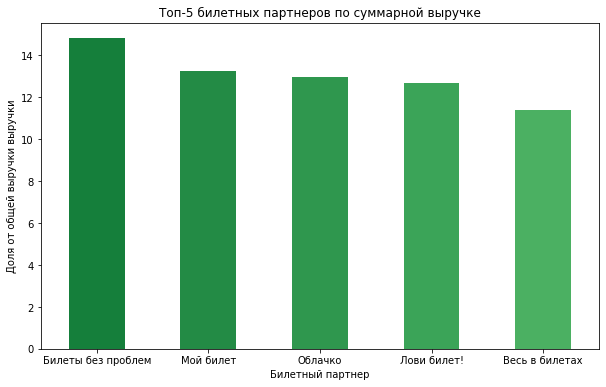

In [69]:
gradient_colors = plt.cm.Greens_r([0.2, 0.25, 0.3, 0.35, 0.4])

top_revenue.plot.bar(x='service_name', y='revenue_share', figsize=(10, 6), color=gradient_colors, legend=False)

plt.xticks(rotation=0)

plt.xlabel('Билетный партнер')
plt.ylabel('Доля от общей выручки выручки')
plt.title('Топ-5 билетных партнеров по суммарной выручке')

plt.grid(False)

plt.show()

In [70]:
bottom_service_name = service_name_pivot.sort_values(by='order_share', ascending=False).tail(15)

print('15 билетных партнеров внизу рейтинга:')
display(bottom_service_name)

15 билетных партнеров внизу рейтинга:


,service_name,event_id,event_share,order_id,order_share,revenue_rub,revenue_share,tickets_count
9,Восьмёрка,92,0.58,390,0.23,238422.406250,0.29,1156.0
27,Радио ticket,7,0.04,322,0.19,44719.949219,0.05,974.0
31,Телебилет,12,0.08,206,0.12,113377.046875,0.14,514.0
29,Росбилет,41,0.26,182,0.11,268650.312500,0.33,462.0
17,КарандашРУ,28,0.18,69,0.04,13689.570312,0.02,233.0
14,Дырокол,2,0.01,62,0.04,88888.882812,0.11,187.0
18,Кино билет,1,0.01,48,0.03,15872.250000,0.02,141.0
2,Билет по телефону,10,0.06,50,0.03,37807.820312,0.05,155.0
10,Вперёд!,21,0.13,38,0.02,14540.019531,0.02,119.0
28,Реестр,4,0.03,15,0.01,12696.099609,0.02,44.0


**15** партнеров внизу топа суммарно дают **~1%** выручки. Вероятно это новые партнеры, которые работают в сервисе недавно, либо организации, работающие в нишевом сегменте (например мероприятия ``18+``). Необходимо дополнительно провести анализ на дополнительных данных. 

#### Промежуточный вывод

Работа сервиса представлена в **79** регионах. Два региона дают **52%** заказов:
Лидерами продаж и по количеству предлагаемых мероприятий являются:
* ``Каменевском регионе`` **29.9%** от всех событий, продажа билетов составляет **27.7%**
* ``Североярской области`` **20.5%** от всех событий, продажа билетов составляет **12.3%**

Всего партнерами сервиса являются **35** организации. Основной объем заказов формируют несколько партнеров, большая часть имеют очень малую долю.

Ключевые билетные партнеры, которые попали в топ-5 по всем категориям:
* Лови билет!
* Билеты без проблем
* Облачко

**42%** партнеров внизу топа суммарно дают ~1% выручки, если это новые партнеры, то стоит посмотреть их долю в динамике через несколько месяцев. Рекомендуется дополнительно провести анализ на дополнительных данных и посмотреть на показатели партнеров в динамике, если они давно представлены на платформе.

## Статистический анализ данных

###  Гипотеза: среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

#### Формулировка гипотезы

* **H0**: Среднее количество заказов одного пользователя мобильного приложения <= cреднее количество заказов одного пользователя стационарных устройств

**μ** *mobile* <= **μ** *desktop*


* **H1**: Среднее количество заказов одного пользователя мобильного приложения > cреднее количество заказов одного пользователя стационарных устройств (*правосторонняя альтернативная гипотеза*) 

**μ** *mobile* > **μ** *desktop*

Уровень значимости alpha = 0.05

In [71]:
autumn_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 168366 entries, 2 to 287106
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                168366 non-null  int32         
 1   user_id                 168366 non-null  object        
 2   created_dt_msk          168366 non-null  datetime64[ns]
 3   created_ts_msk          168366 non-null  datetime64[ns]
 4   event_id                168366 non-null  int32         
 5   cinema_circuit          168366 non-null  bool          
 6   age_limit               168366 non-null  category      
 7   currency_code           168366 non-null  category      
 8   device_type_canonical   168366 non-null  category      
 9   revenue                 168366 non-null  float32       
 10  service_name            168366 non-null  object        
 11  tickets_count           168366 non-null  int8          
 12  total                   168366

In [72]:
df_mobile = autumn_df.query('device_type_canonical=="mobile"')
df_desktop = autumn_df.query('device_type_canonical=="desktop"')

print('Всего в датафрейме уникальных пользователей:', autumn_df['user_id'].nunique())
print('Всего в выборке заказов с мобильных устройств уникальных пользователей:', df_mobile['user_id'].nunique())
print(f'Всего в выборке заказов со стационарных устройств уникальных пользователей:', df_desktop['user_id'].nunique())

Всего в датафрейме уникальных пользователей: 15800
Всего в выборке заказов с мобильных устройств уникальных пользователей: 14180
Всего в выборке заказов со стационарных устройств уникальных пользователей: 4868


#### Подготовка данных и формирование выборок

Сформируем 2 непересекающиеся выборки

In [73]:
user_device_types = autumn_df.groupby('user_id')['device_type_canonical'].nunique()
users_with_one_device = user_device_types[user_device_types == 1].index
df_device = autumn_df[autumn_df['user_id'].isin(users_with_one_device)].copy()

mobile = df_device.query('device_type_canonical=="mobile"')
desktop = df_device.query('device_type_canonical=="desktop"')

intersection = list(set(mobile['user_id']) & set(desktop['user_id']))
print('Пересекающиеся пользователи:', intersection) 

print(mobile['user_id'].nunique(), desktop['user_id'].nunique())
print('Доля пользователей мобильных устройств', mobile['user_id'].nunique()/df_device['user_id'].nunique())
print('Доля пользователей стационарных устройств', desktop['user_id'].nunique()/df_device['user_id'].nunique())

Пересекающиеся пользователи: []
10932 1620
Доля пользователей мобильных устройств 0.8709369024856597
Доля пользователей стационарных устройств 0.12906309751434034


Для проверки гипотезы о различии в среднем количестве заказов между пользователями мобильных и стационарных устройств необходимо, чтобы выборки были независимыми. Пользователи, которые совершали заказы как с мобильных, так и с десктопных устройств, создают пересечение между группами, что нарушает предпосылку независимости и может исказить результаты статистического теста. Поэтому из анализа были исключены пользователи, использовавшие оба типа устройств (20% от общего числа уникальных пользователей). Это позволило сформировать две непересекающиеся группы: только мобильные (**10 932** пользователей) и только десктопные (**1 610** пользователей). Выборки не равномерны, соизмеримо соотношению количества заказов с мобильных и ПК.

#### Распределение данных

Расчитаем ключевую метрику - количество заказов на одного пользователя и посмотрим распределение данных

In [74]:
mobile_df = mobile.groupby('user_id')['order_id'].count().reset_index()
desktop_df = desktop.groupby('user_id')['order_id'].count().reset_index()

mobile = mobile_df['order_id']
desktop = desktop_df['order_id']

In [75]:
print('mobile:\n', mobile.describe())
print('desktop:\n', desktop.describe())

mobile:
 count    10932.000000
mean         2.856293
std          4.096441
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max        123.000000
Name: order_id, dtype: float64
desktop:
 count    1620.000000
mean        1.974074
std         3.060529
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        56.000000
Name: order_id, dtype: float64


``mobile``:
среднее значение **2.85**, медиана **2**, в данных наблюдается сильный правый хвост, есть выбросы, увеличивающие среднее значение, разброс большой от 1 билета до 123, есть пользователи с аномально высоким количеством заказов.

``desktop``:
среднее значение **1.97**, медиана **1**, в данных также наблюдается сильный правый хвост, есть выбросы, увеличивающие среднее значение,
разброс большой от 1 билета до 56, есть пользователи с аномально высоким количеством заказов.

Оба распределения имеют выраженную правостороннюю асимметрию с наличием единичных пользователей с аномально высоким количеством заказов.


In [76]:
avg_mobile = round(mobile.mean(), 2)
avg_desktop = round(desktop.mean(), 2)

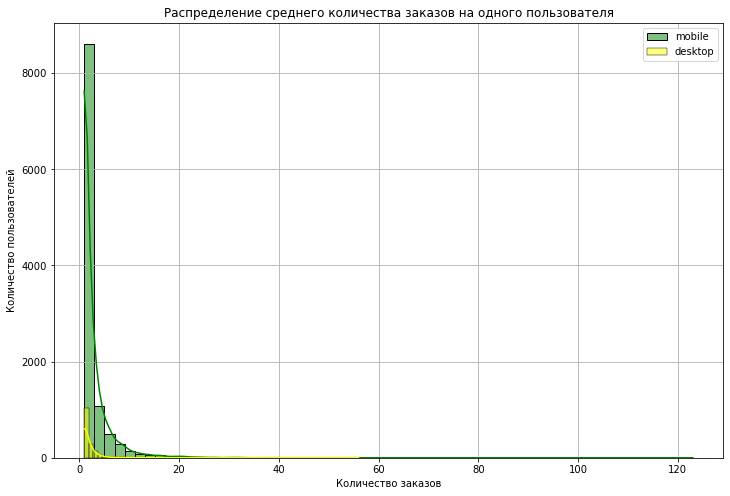

In [77]:
plt.figure(figsize=(12, 8))

sns.histplot(mobile, bins=60, color='green', kde=True, label='mobile')
sns.histplot(desktop, bins=60, color='yellow', kde=True, label='desktop')
plt.title('Распределение среднего количества заказов на одного пользователя')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')

plt.legend()
plt.grid(True)
plt.show()

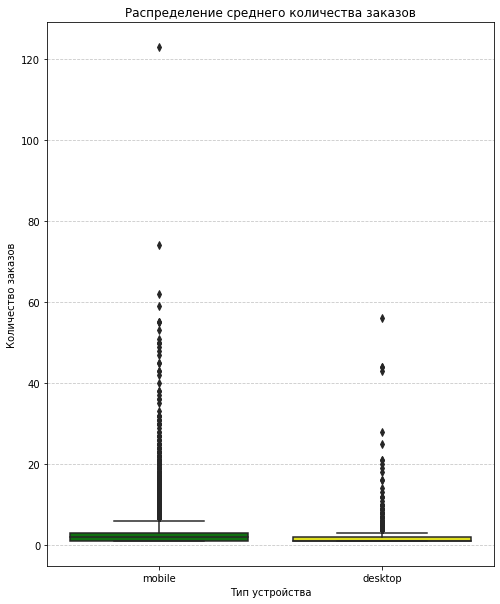

In [78]:
plt.figure(figsize=(8, 10))

sns.boxplot(data=[mobile, desktop], palette=['green', 'yellow'])
plt.xticks([0, 1], ['mobile', 'desktop'])

plt.title('Распределение среднего количества заказов')
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

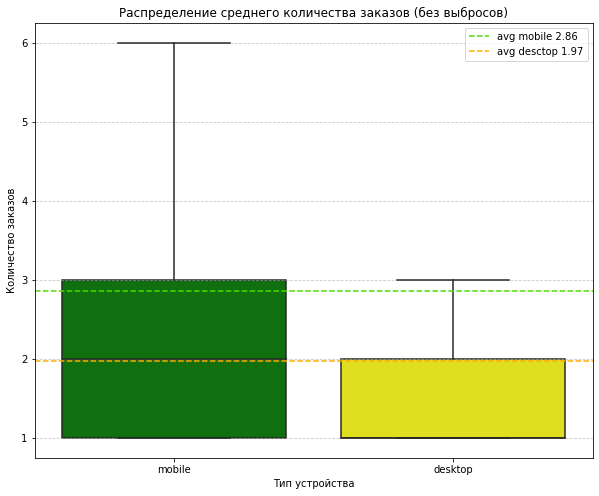

In [79]:
plt.figure(figsize=(10, 8))

sns.boxplot(data=[mobile, desktop], palette=['green', 'yellow'], showfliers=False)
plt.xticks([0, 1], ['mobile', 'desktop'])

plt.axhline(avg_mobile, linestyle='--', linewidth = 1.5, color='#4dde00', label=f'avg mobile {avg_mobile}')
plt.axhline(avg_desktop, linestyle='--', linewidth = 1.5, color='#ffaa00', label=f'avg desctop {avg_desktop}')

plt.title('Распределение среднего количества заказов (без выбросов)')
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Определяем статистический тест:
Для проверки гипотезы о различии среднего количества заказов между пользователями мобильных и стационарных устройств используем **t-тест Уэлча**. Он предназначен для сравнения средних в двух независимых выборках, не требует равенства дисперсий и хорошо работает при больших выборках. Несмотря на наличие выбросов в данных, большой размер выборок (14 737 и 2 131 наблюдений) позволяет считать распределение выборочного среднего приблизительно нормальным.

Уровень значимости **alpha = 0.05**

####  t-тест Уэлча

In [80]:
alpha = 0.05

stat_ttest, p_value_welch_ttest = ttest_ind(
    mobile, 
    desktop, 
    alternative='greater',
    equal_var=False) 

if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча = {p_value_welch_ttest}')
    print('Не удалось отвергнуть нулевую гипотезу, различия в выборочных средних в группах mobile и desktop не являются статистически значимыми.')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения, выборочные средние в группах mobile и desktop не равны.\nСреднее количество заказов пользователей мобильных устройств статистически выше среднего количества заказов пользователей десктопных версий.')

p-value теста Уэлча =0.0
Нулевая гипотеза не находит подтверждения, выборочные средние в группах mobile и desktop не равны.
Среднее количество заказов пользователей мобильных устройств статистически выше среднего количества заказов пользователей десктопных версий.


Т-Тест Уэлча проведен на двух непересекающихся выборках:

* mobile **10 932**

* desktop **1 620**

Дисперсии выборок различаются, в данных наблюдаются  экстремально высокие значения, распределение данных правостороннее.

Нулевая гипотеза не нашла подтверждение, есть статистически значимые доказательства того, что среднее количество заказов пользователей мобильных устройств выше, чем у пользователей стационарных устройств (p-value < 0.001).

#####  t-тест Уэлча на данных без выбросов

Дополнительно проведем тест Уэлча очищенных от выбросов данных, ограничив их 99-м процентилем.


In [81]:
mobile_99_per = mobile_df['order_id'].quantile(0.99)
desktop_99_per = desktop_df['order_id'].quantile(0.99)

mobile_99 =  mobile_df[mobile_df['order_id']<mobile_99_per]
desktop_99 =  desktop_df[desktop_df['order_id']<desktop_99_per]

mobile_a = mobile_99['order_id']
desktop_b = desktop_99['order_id']

print(mobile_a.describe())
print(desktop_b.describe())

count    10822.000000
mean         2.575772
std          2.647329
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: order_id, dtype: float64
count    1602.000000
mean        1.725343
std         1.406497
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: order_id, dtype: float64


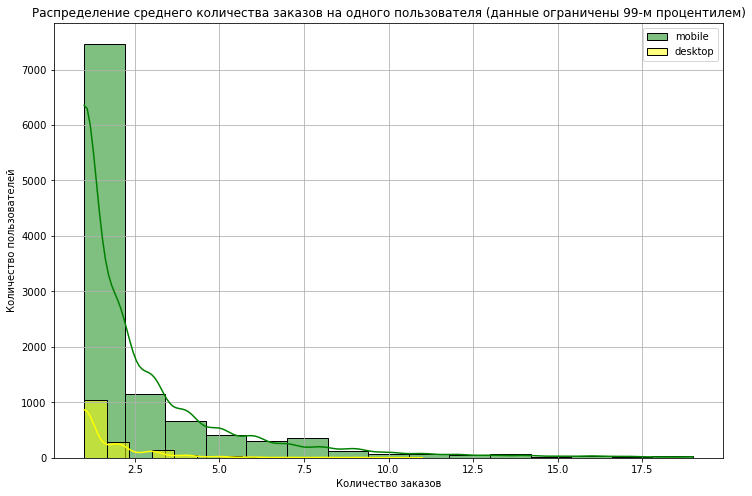

In [82]:
plt.figure(figsize=(12, 8))

sns.histplot(mobile_a, bins=15, color='green', kde=True, label='mobile')
sns.histplot(desktop_b, bins=15, color='yellow', kde=True, label='desktop')

plt.title('Распределение среднего количества заказов на одного пользователя (данные ограничены 99-м процентилем)')
plt.xlabel('Количество заказов')
plt.ylabel('Количество пользователей')

plt.legend()
plt.grid(True)
plt.show()

На очищенных от выбросов данных также наблюдается правосторонняя асиметрия.
* в группе ``mobile`` максимальное значение упало с 123 до 19, а среднее снизилось с 2.85 до 2.57 (выборка **10 821** )
* в группе ``desktop`` максимум упал с 56 до 11, а среднее снизилось с 1.97 до 1.72 (выборка **1 602**)

In [83]:
alpha = 0.05

stat_ttest, p_value_welch_ttest = ttest_ind(
    mobile_a, 
    desktop_b, 
    alternative='greater',
    equal_var=False) 

if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча = {p_value_welch_ttest}')
    print('Не удалось отвергнуть нулевую гипотезу, различия в выборочных средних в группах mobile и desktop не являются статистически значимыми.')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения, выборочные средние в группах mobile и desktop не равны.\nСреднее количество заказов пользователей мобильных устройств статистически выше среднего количества заказов пользователей десктопных версий.')

p-value теста Уэлча =0.0
Нулевая гипотеза не находит подтверждения, выборочные средние в группах mobile и desktop не равны.
Среднее количество заказов пользователей мобильных устройств статистически выше среднего количества заказов пользователей десктопных версий.


На очищенных от выбросов данных нулевая гипотеза также не находит подтверждения,  есть статистически значимые доказательства того, что среднее количество заказов пользователей мобильных устройств выше, чем у пользователей стационарных устройств (p-value < 0.001).

#### Интерпретация 

На основе данных за осенний период с 01.09.24 по 31.10.24 проведена проверка гипотезы о том, что среднее количество заказов на одного пользователя мобильного приложения выше, чем у пользователей стационарных устройств. 

Для обеспечения независимости выборок из анализа были исключены пользователи, совершавшие заказы с обоих типов устройств (20% от общего числа уникальных пользователей). 

В результате сформированы две непересекающиеся группы: только мобильные устройства (**10 932** пользователей) и только десктопные устройства (**1 620** пользователь). Распределение количества заказов отличается от нормального, однако размер выборок достаточно большой, что позволяет использовать t-тест Уэлча. Дополнительно для устойчивости результатов анализ проведен на данных без выбросов.

Результаты t-теста Уэлча (правосторонний):

* Среднее количество заказов в группе мобильных пользователей: **2.85** (медиана 2)

* Среднее количество заказов в группе десктопных пользователей: **1.97** (медиана 1)

* **p-value теста: ≈ 0.0 (< 0.001)**

* Дополнительно проведен тест на данных, ограниченых от выбросов 99-м процентилем, средние значения снизились до 2.57 (мобильные) и 1.72 (десктопные), разница осталась статистически значимой (p-value < 0.001), что подтверждает устойчивость вывода.

Нулевая гипотеза не находит подтверждения на уровне значимости alpha =0.05. 
Принимается альтернативная гипотеза: среднее количество заказов на одного пользователя мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

**Полученные результаты показывают, что мобильные пользователи демонстрируют более высокую покупательскую активность по сравнению с десктопными.**


###  Гипотеза: среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

#### Формулировка гипотезы

* **H0**: Среднее время между заказами пользователей мобильного приложения <= среднее время между заказами пользователей стационарных устройств

**μ** *mobile* <= **μ** *desktop*


* **H1**: Среднее время между заказами пользователей мобильного приложения > среднее время между заказами пользователей стационарных устройств (*правосторонняя альтернативная гипотеза*) 

**μ** *mobile* > **μ** *desktop*

Уровень значимости alpha = 0.05

#### Подготовка данных и формирование выборок

Независимая выборка с пользователями только ``mobile`` и ``desktop`` уже есть - **df_device**. Отфильтруем пользователей с > 1 заказом.

In [84]:
order_count_df = df_device.copy()
order_count_df['order_count'] = df_device.groupby('user_id')['order_id'].transform('count')

order_count_df.info()
display(order_count_df.head())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 34423 entries, 2 to 287106
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                34423 non-null  int32         
 1   user_id                 34423 non-null  object        
 2   created_dt_msk          34423 non-null  datetime64[ns]
 3   created_ts_msk          34423 non-null  datetime64[ns]
 4   event_id                34423 non-null  int32         
 5   cinema_circuit          34423 non-null  bool          
 6   age_limit               34423 non-null  category      
 7   currency_code           34423 non-null  category      
 8   device_type_canonical   34423 non-null  category      
 9   revenue                 34423 non-null  float32       
 10  service_name            34423 non-null  object        
 11  tickets_count           34423 non-null  int8          
 12  total                   34423 non-null  float

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,city_name,city_id,venue_id,venue_name,venue_address,revenue_rub,one_ticket_revenue_rub,month,season,order_count
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,False,0,rub,mobile,1258.569946,...,Глиногорск,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",1258.569946,314.640015,10,осень,1
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,False,18,rub,mobile,1390.410034,...,Родниковецк,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",1390.410034,463.470001,10,осень,2
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,False,12,rub,mobile,902.739990,...,Кристалевск,193,930,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",902.739990,300.910004,10,осень,2
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,False,12,rub,mobile,47.779999,...,Дальнозолотск,18,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",47.779999,47.779999,9,осень,2
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,False,12,rub,mobile,74.839996,...,Дальнозолотск,18,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",74.839996,37.419998,10,осень,2


In [85]:
period_df = order_count_df.query('order_count > 1')

period_df.info()

print('Минимальное значение количества заказов на пользователя:', period_df['order_count'].min())
print(f'Осталось строк {len(period_df)} из {len(order_count_df)}')


<class 'pandas.core.frame.DataFrame'>
Int64Index: 28011 entries, 4 to 287106
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                28011 non-null  int32         
 1   user_id                 28011 non-null  object        
 2   created_dt_msk          28011 non-null  datetime64[ns]
 3   created_ts_msk          28011 non-null  datetime64[ns]
 4   event_id                28011 non-null  int32         
 5   cinema_circuit          28011 non-null  bool          
 6   age_limit               28011 non-null  category      
 7   currency_code           28011 non-null  category      
 8   device_type_canonical   28011 non-null  category      
 9   revenue                 28011 non-null  float32       
 10  service_name            28011 non-null  object        
 11  tickets_count           28011 non-null  int8          
 12  total                   28011 non-null  float

Осталось 28014 строк из 34426 (**81%**) с данными о пользователях, у которых более 1 заказа.

В значениях ``days_since_prev`` есть значения 0, если покупатель сделал несколько заказов в один день.

В датафрейме есть **3 186** пустых значений в поле ``days_since_prev``, это первый заказ пользователя.

Для проверки гипотезы о среднем времени между заказами, создан датафрейм **period_df** из непересекающихся пользователей, у которых минимум 2 заказа. Далее необходимо разделить  добавить метрику **среднее время между заказами** на основе столбца ``days_since_prev`` 

In [86]:
mobile_users = period_df.query('device_type_canonical=="mobile"')
desktop_users = period_df.query('device_type_canonical=="desktop"')

intersection = list(set(mobile_users['user_id']) & set(desktop_users['user_id']))
print('Пересекающиеся пользователи:', intersection) 

print(mobile_users['user_id'].nunique(), desktop_users['user_id'].nunique())
print('Доля пользователей мобильных устройств', mobile_users['user_id'].nunique()/period_df['user_id'].nunique())
print('Доля пользователей стационарных устройств', desktop_users['user_id'].nunique()/period_df['user_id'].nunique())

Пересекающиеся пользователи: []
5561 579
Доля пользователей мобильных устройств 0.905700325732899
Доля пользователей стационарных устройств 0.09429967426710098


В результате подготовки данных к проверке гипотезы из анализа были исключены пользователи с 1 заказом, сформировано 2 группы данных:
* ``mobile`` 5 561 пользователь
* ``desktop`` 579 пользователей

* Предпосылка о независимости данных соблюдается, пересечений нет
* Размер выборок достаточен для проведения теста


#### Распределение данных
Расчитаем ключевую метрику - среднее время между заказами у одного пользователя и посмотрим распределение данных

In [87]:
mobile_data = mobile_users.groupby('user_id')['days_since_prev'].mean().reset_index()
desktop_data = desktop_users.groupby('user_id')['days_since_prev'].mean().reset_index()

mobile = mobile_data['days_since_prev']
desktop = desktop_data['days_since_prev']

In [88]:
print('mobile:\n', mobile.describe())
print('desktop:\n', desktop.describe())

mobile:
 count    5561.000000
mean       13.377152
std        14.725312
min         0.000000
25%         0.500000
50%         8.777778
75%        20.666666
max        73.500000
Name: days_since_prev, dtype: float64
desktop:
 count    579.000000
mean      10.540702
std       15.419126
min        0.000000
25%        0.000000
50%        1.400000
75%       16.500000
max       71.500000
Name: days_since_prev, dtype: float64


``mobile``:
среднее значение **13.39**, медиана **8.7**, в данных наблюдается сильный правый хвост, есть выбросы, увеличивающие среднее значение, разброс от 0 до 73.5 дня, есть пользователи с аномально высоким среднем временем между заказами.

``desktop``:
среднее значение **10.54**, медиана **1.4**, в данных также наблюдается сильный правый хвост, есть выбросы, увеличивающие среднее значение, разброс от 0 билета до 71.5, есть пользователи с аномально высоким среднем временем между заказами.

In [89]:
avg_time_mobile = round(mobile.mean(), 2)
avg_time_desktop = round(desktop.mean(), 2)

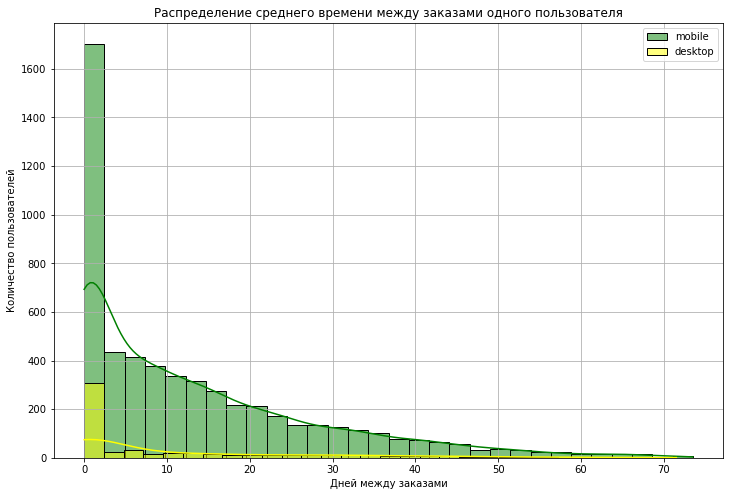

In [90]:
plt.figure(figsize=(12, 8))

sns.histplot(mobile, bins=30, color='green', kde=True, label='mobile')
sns.histplot(desktop, bins=30, color='yellow', kde=True, label='desktop')
plt.title('Распределение среднего времени между заказами одного пользователя')
plt.xlabel('Дней между заказами')
plt.ylabel('Количество пользователей')

plt.legend()
plt.grid(True)
plt.show()

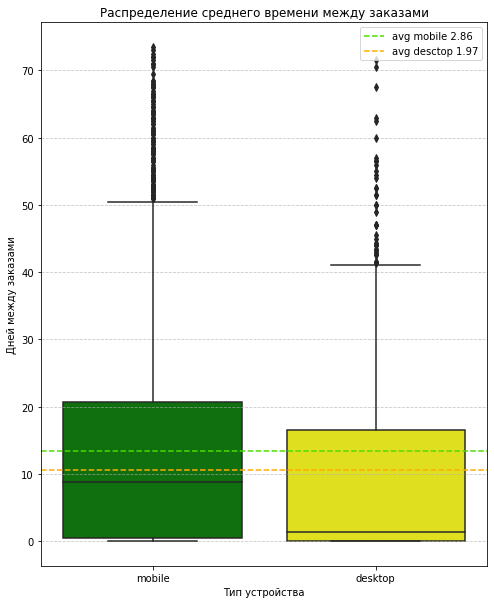

In [91]:
plt.figure(figsize=(8, 10))

sns.boxplot(data=[mobile, desktop], palette=['green', 'yellow'])
plt.xticks([0, 1], ['mobile', 'desktop'])

plt.axhline(avg_time_mobile, linestyle='--', linewidth = 1.5, color='#4dde00', label=f'avg mobile {avg_mobile}')
plt.axhline(avg_time_desktop, linestyle='--', linewidth = 1.5, color='#ffaa00', label=f'avg desctop {avg_desktop}')

plt.title('Распределение среднего времени между заказами')
plt.xlabel('Тип устройства')
plt.ylabel('Дней между заказами')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Распределения среднего времени между заказами в обеих группах имеют схожую правостороннюю асимметрию, что подтверждается визуально. Стандартные отклонения близки (**14.75** у мобильных и **15.42** у десктопных). 

Однако центральные тенденции различаются: медиана в группе мобильных (**8.78** дня) значительно выше, чем в группе десктопных (**1.4** дня). Среднее значение у мобильных (**13.4** дня) также выше, чем у десктопных (**10.5** дня). 

Это говорит о том, что типичный мобильный пользователь совершает повторные покупки реже (с большими интервалами), чем десктопный, несмотря на сходный разброс значений.

Для проверки гипотезы о различии среднего времени между заказами для пользователей мобильных и стационарных устройств также используем **t-тест Уэлча**. Он предназначен для сравнения средних в двух независимых выборках, не требует равенства дисперсий и хорошо работает при больших выборках. Несмотря на наличие выбросов в данных, размер выборок (5 561 и 579 наблюдений) позволяет считать распределение выборочного среднего приблизительно нормальным. Распределение в данных схожее.

Уровень значимости **alpha = 0.05**

####  t-тест Уэлча

In [92]:
alpha = 0.05

stat_ttest, p_value_welch_ttest = ttest_ind(
    mobile, 
    desktop, 
    alternative='greater',
    equal_var=False) 

if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча = {round(p_value_welch_ttest, 4)}')
    print('Не удалось отвергнуть нулевую гипотезу, различия в выборочных средних в группах mobile и desktop не являются статистически значимыми.')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 4)}')
    print('Нулевая гипотеза не находит подтверждения, выборочные средние в группах mobile и desktop не равны.\nСреднее время между заказами пользователей мобильных устройств статистически выше пользователей десктопных версий.')

p-value теста Уэлча =0.0
Нулевая гипотеза не находит подтверждения, выборочные средние в группах mobile и desktop не равны.
Среднее время между заказами пользователей мобильных устройств статистически выше пользователей десктопных версий.


#### Интерпретация 

На основе данных за осенний период с 01.09.24 по 31.10.24 проведена проверка гипотезы о том, что среднее время между заказами одного пользователя мобильного приложения выше, чем у пользователя стационарного устройства. 

Для обеспечения независимости выборок из анализа были исключены пользователи, совершавшие заказы с обоих типов устройств (20% от общего числа уникальных пользователей), а также пользователи, у которых было не более 1 заказа.

В результате сформированы две непересекающиеся группы: только мобильные устройства (**5 561** пользователь) и только десктопные устройства (**579** пользователей). Распределения среднего времени между заказами в обеих группах имеют схожую правостороннюю асимметрию, стандартные отклонения близки (**14.75** у мобильных и **15.42** у десктопных).
Проведен правосторонний параметрический t-тест Уэлча.

Результаты t-теста Уэлча (правосторонний):

* Среднее время между заказами в группе мобильных пользователей: 13.39 (медиана 8.77)

* Среднее время между заказами в группе десктопных пользователей: 10.54 (медиана 1.4)

* **p-value теста: ≈ 0.0 (< 0.001)**

Нулевая гипотеза не находит подтверждения на уровне значимости alpha =0.05. Принимается альтернативная гипотеза: среднее количество заказов на одного пользователя мобильных устройств статистически значимо выше, чем у пользователей стационарных устройств.

**Полученные результаты показывают, что мобильные пользователи в среднем имеют большие интервалы между заказами.**

## Общий вывод и рекомендации

В рамках проекта был проведен исследовательский анализ данных сервиса Яндекс Афиша о по продаже билетов на мероприятия за период с 01.06.24г. по 31.10.24г. Предоставлено 3 датасета, которые были объединены в ходе исследования.

После предобработки данные были очищены от дубликатов, обработаны пропуски и аномальные значения, выручка была приведена к единой валюте — российским рублям. Также были созданы дополнительные признаки для анализа: 
* сезонность
* средняя стоимость билета

После предобработки данных осталось **287 109** строк, **98.72%** от первоначального датафрейма.

*Осенний период в данных ограничена 2 месяцами, поэтому полный анализ стоит провести после закрытия ноября, однако динамика на изменение пользовательского поведения видна и в рамках текущего исследования.*

**Наиболее востребованные мероприятия**

* ``концерты``
* ``театр``
* ``категория другое`` 

``Концерты`` являются абсолютным лидером как по количеству заказов, так и по средней выручке с билета.

``Театральные мероприятия`` стабильно занимают второе место и показывают высокий спрос в осенний период (**20.2%** летом, **25.4%** осенью) в связи с началом театрального сезона и конца сезона отпусков.

Категория ``другое`` на третьем месте по количеству заказов, летом занимает второй по популярности сегмент (**27%** летом, **19.6%** осенью). Для более детального изучения необходимы дополнительные данные, о том, какие мероприятия входят в данный сегмент.

Также осенью значительный рост показывают ``спортивные мероприятия``, рост в абсолютном соотношении до **15 859 заказов**, в относительном значении рост на **8.7 п.п.**, что соответсвует началу сезона спортивных мероприятий.

Осенью меняется структура спроса, количество пользователей растет в связи с тем, что летние виды досуга становятся менее доступными, люди переключаются на мероприятия, проводимые в городе.


``Ёлки``, несмотря на малую долю (**0.2%** летом, **1.0%** осенью), показывают абсолютный рост в 6 раз, что указывает на раннее начало пред-новогодних продаж.

Исследование подтвердило выраженную сезонность пользовательского спроса: от августа к сентябрю количество заказов выросло на **55.5%** (с **44 522** в августе до **69 231** в сентябре).

Осенью наблюдается тренд на увеличение количества заказов и количества пользователей. При этом рост числа заказов опережает рост количества уникальных покупателей: начиная с сентября пользователи сервиса чаще делают заказы. 

Летом пользователи совершают меньше покупок, но чаще приобретают более дорогие билеты (например, на фестивали и крупные сезонные мероприятия). 

**Изменение стоимости среднего чека**

Средняя выручка с билета осенью падает до **178.2 руб.** (на 14% ниже летнего периода 208.5 руб.).
Это также связано с изменением структуры рынка осенью - масштабные фестивали и опен-эйры проводятся существенно реже, растет запрос на мероприятия, доступные в закрытых помещениях, которые не зависят от погоды.

**Пользовательская активность**

Анализ DAU показал наличие выраженной недельной цикличности:
пользователи активнее всего оформляют покупки в пятницу, меньше всего в понедельник и воскресенье. 
При низкой активности в воскресенье, в эти дни самый высокий средний чек заказа (**200 руб**)

Зафиксированы 2 пика всплеска активности пользователей при падении среднего чека (менее **100 руб.**) - **03.09.24** и **01.10.24** - эти дни являются первым вторником месяца, вероятно в эти дни проходит регулярная маркетинговая активность.

**Лидеры среди регионов и партнеров**

Всего на сервисе представлено **3 522 организации-партнера** в **79 регионах**.

**Лидеры по регионам:**

* ``Каменевский регион`` продажа билетов составляет **27.7%**, а также регион является лидером по доле предлагаемых мероприятий **29.9%**.
*  ``Североярская область`` продажа билетов составляе **12.3%**, доля предлагаемых мероприятий **20.5%**

**Лидеры по организаторам-партнерам:**

Всего партнерами сервиса являются 35 организации. Основной объем заказов формируют несколько партнеров, большая часть имеют очень малую долю. Первая 10-ка билетных партнеров формируют **91%** всей выручки и предлагают 97% мероприятий.

Ключевые билетные партнеры, которые попали в топ-5 по всем категориям:
* Лови билет!
* Билеты без проблем
* Облачко

Рекомендуется дополнительно провести анализ на дополнительных данных и посмотреть на показатели партнеров в динамике, если они давно представлены на платформе.

**Мобильное приложение и стационарные устройсва**

Более половины пользователей пользуются ``мобильным приложением``, их процент составляет **~80%**


**Результат проверки гипотез**

При проверке гипотез были взяты данные за осенний период, оставлены пользователи оформляющие заказ только с ``мобильных устройств`` и только с ``десктопных устройств``. Для обоих гипотез был применен правосторонний параметрический t-тест Уэлча, с уровнем значимости alpha = 0.05.

В результате проверки гипотез были выявлены статистически значимые различия между пользователями ``мобильных устройств`` и ``стационарных`` по среднему числу заказов и среднему времени между заказами пользователя.

Пользователи ``мобильных устройств`` в среднем оформляют больше заказов на одного пользователя по сравнению с пользователями ``стационарных устройств``. При этом средний интервал между заказами у ``мобильных пользователей`` также оказался выше.

Следует учитывать неоднородность групп - ``мобильные`` пользователи в целом демонстрируют более высокую частоту покупок (среднее число заказов выше), что связано с меньшей долей пользователей с одним заказов, по сравнению с ``десктопной`` группой. 
Cреди пользователей, совершающих повторные покупки, ``мобильные`` с бо́льшими интервалами, а ``десктопные`` — чаще, но таких пользователей в десктопной группе значительно меньше. 

Полученные результаты могут указывать на различия пользовательских сценариев между мобильной и десктопной аудиторией сервиса.

**Рекомендации**

* Провести детальную разбивку категории ``другое`` для лучшего таргетинга.


* Работа с возрастными группами: растущий спрос на мероприятия 0+ и 12+ требует расширения семейного контента. 


* Проанализировать эффективность маркетинговой акции (пики активности 3 сентября и 1 октября с низким средним чеком).


* Расширять совместные маркетинговые активности с одним из ключевых партнеров ``Лови билет!``: есть потенциал для увеличения конверсии, на данный момент при 22.8% мероприятий, доля в выручке 12.69%


* Категория ``ёлки`` показывает рост в абсолютном значении в 6 раз от августа к сентябрю, наиболее выраженный рост — количество заказов увеличилось почти в 6 раз. Необходимо учитывать ранний рост интереса к данной категории при планировании маркетинговых активностей: запускать продвижение новогодних мероприятий уже в сентябре, расширять ассортимент популярных детских и праздничных событий.

* По регионам: 
    * в ``Североярской области`` провести дополнительное иследование конверсии продаж, так как доля предлагаемых мероприятий опережает долю продаж в регионе.
    * ``Медовская область`` занимает третье место по объему продаж при небольшой доле предлагаемых мероприятий 2.32%. В области виден высокий спрос на мероприятия, стоит рассмотреть возможность расширения 'ассортимента' билетов.
    
* Для пользователей ``мобильного приложения``  оптимизировать пуш-уведомления (проверить эффективность сущестующих), это позволит присылать пользователям более релевантные рекомендации на основе их прошлых покупок и сократит время между заказами.